<style>
/* Thicken the divider line in VS Code's split view */
.monaco-workbench .split-view .resize-sash {
    width: 10px !important;
}
</style>

# exploración con openai

### basado en

con el código de https://www.kaggle.com/learn-guide/5-day-genai?utm_medium=email&utm_source=gamma&utm_campaign=learn-5daygenai

### intro a genAI y prompting

In [1]:
# from dotenv import load_dotenv
import os

from IPython.display import HTML, Markdown, display
import pandas as pd
import openai


GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')  # Retrieve the API key
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')  # Retrieve the API key

#### prompting

In [2]:
# # zero-shot

# model_config = types.GenerateContentConfig(
#     temperature=0.1,
#     top_p=1,
#     max_output_tokens=5,
# )

# zero_shot_prompt = """Classify evaluations of movie subjects (ie, how the reviewer sees the object portrayed) as POSITIVE, NEUTRAL or NEGATIVE.
# Review: "Her" is a disturbing study revealing the direction
# humanity is headed if AI is allowed to keep evolving,
# unchecked. I wish there were more movies like this masterpiece.
# Sentiment: """

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=model_config,
#     contents=zero_shot_prompt)

# print(response.text)

In [3]:
# # enum restringe el tipo de respuesta a un conjunto de valores predefinidos

# import enum

# class Sentiment(enum.Enum):
#     POSITIVE = "positive"
#     NEUTRAL = "neutral"
#     NEGATIVE = "negative"


# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=types.GenerateContentConfig(
#         response_mime_type="text/x.enum",
#         response_schema=Sentiment
#     ),
#     contents=zero_shot_prompt)

# print(response.parsed)

In [4]:
# enum_response = response.parsed
# print(enum_response)
# print(type(enum_response))

In [5]:
# # one, few-shot
# few_shot_prompt = """Parse a customer's pizza order into valid JSON:

# EXAMPLE:
# I want a small pizza with cheese, tomato sauce, and pepperoni.
# JSON Response:
# ```
# {
# "size": "small",
# "type": "normal",
# "ingredients": ["cheese", "tomato sauce", "pepperoni"]
# }
# ```

# EXAMPLE:
# Can I get a large pizza with tomato sauce, basil and mozzarella
# JSON Response:
# ```
# {
# "size": "large",
# "type": "normal",
# "ingredients": ["tomato sauce", "basil", "mozzarella"]
# }
# ```

# ORDER:
# """

# customer_order = "Give me a large with cheese & pineapple"

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=types.GenerateContentConfig(
#         temperature=0.1,
#         top_p=1,
#         max_output_tokens=250,
#     ),
#     contents=[few_shot_prompt, customer_order])

# Markdown(response.text)

In [6]:
# # forzar el formato de salida a json
# import typing_extensions as typing

# class PizzaOrder(typing.TypedDict):
#     size: str
#     ingredients: list[str]
#     type: str


# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=types.GenerateContentConfig(
#         temperature=0.1,
#         response_mime_type="application/json",
#         response_schema=PizzaOrder,
#     ),
#     contents="Can I have a large dessert pizza with apple and chocolate")

# Markdown(response.text)

#### Chain of Thought

In [7]:
# prompt = """When I was 4 years old, my partner was 3 times my age. Now, I
# am 20 years old. How old is my partner? Return the answer directly."""

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     contents=prompt)

# print(response.text)

In [8]:
# prompt = """When I was 4 years old, my partner was 3 times my age. Now,
# I am 20 years old. How old is my partner? Let's think step by step."""

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     contents=prompt)

# Markdown(response.text)

In [9]:
# # REACT
# model_instructions = """
# Solve a question answering task with interleaving Thought, Action, Observation steps. Thought can reason about the current situation,
# Observation is understanding relevant information from an Action's output and Action can be one of three types:
#  (1) <search>entity</search>, which searches the exact entity on Wikipedia and returns the first paragraph if it exists. If not, it
#      will return some similar entities to search and you can try to search the information from those topics.
#  (2) <lookup>keyword</lookup>, which returns the next sentence containing keyword in the current context. This only does exact matches,
#      so keep your searches short.
#  (3) <finish>answer</finish>, which returns the answer and finishes the task.
# """

# example1 = """Question
# Musician and satirist Allie Goertz wrote a song about the "The Simpsons" character Milhouse, who Matt Groening named after who?

# Thought 1
# The question simplifies to "The Simpsons" character Milhouse is named after who. I only need to search Milhouse and find who it is named after.

# Action 1
# <search>Milhouse</search>

# Observation 1
# Milhouse Mussolini Van Houten is a recurring character in the Fox animated television series The Simpsons voiced by Pamela Hayden and created by Matt Groening.

# Thought 2
# The paragraph does not tell who Milhouse is named after, maybe I can look up "named after".

# Action 2
# <lookup>named after</lookup>

# Observation 2
# Milhouse was named after U.S. president Richard Nixon, whose middle name was Milhous.

# Thought 3
# Milhouse was named after U.S. president Richard Nixon, so the answer is Richard Nixon.

# Action 3
# <finish>Richard Nixon</finish>
# """

# example2 = """Question
# What is the elevation range for the area that the eastern sector of the Colorado orogeny extends into?

# Thought 1
# I need to search Colorado orogeny, find the area that the eastern sector of the Colorado orogeny extends into, then find the elevation range of the area.

# Action 1
# <search>Colorado orogeny</search>

# Observation 1
# The Colorado orogeny was an episode of mountain building (an orogeny) in Colorado and surrounding areas.

# Thought 2
# It does not mention the eastern sector. So I need to look up eastern sector.

# Action 2
# <lookup>eastern sector</lookup>

# Observation 2
# The eastern sector extends into the High Plains and is called the Central Plains orogeny.

# Thought 3
# The eastern sector of Colorado orogeny extends into the High Plains. So I need to search High Plains and find its elevation range.

# Action 3
# <search>High Plains</search>

# Observation 3
# High Plains refers to one of two distinct land regions

# Thought 4
# I need to instead search High Plains (United States).

# Action 4
# <search>High Plains (United States)</search>

# Observation 4
# The High Plains are a subregion of the Great Plains. From east to west, the High Plains rise in elevation from around 1,800 to 7,000 ft (550 to 2,130m).

# Thought 5
# High Plains rise in elevation from around 1,800 to 7,000 ft, so the answer is 1,800 to 7,000 ft.

# Action 5
# <finish>1,800 to 7,000 ft</finish>
# """

# # Come up with more examples yourself, or take a look through https://github.com/ysymyth/ReAct/

In [10]:
# question = """Question
# Who was the youngest author listed on the transformers NLP paper?
# """

# # You will perform the Action; so generate up to, but not including, the Observation.
# react_config = types.GenerateContentConfig(
#     stop_sequences=["\nObservation"],
#     system_instruction=model_instructions + example1 + example2,
# )

# # Create a chat that has the model instructions and examples pre-seeded.
# react_chat = client.chats.create(
#     model='gemini-2.0-flash',
#     config=react_config,
# )

# resp = react_chat.send_message(question)
# print(resp.text)

In [11]:
# observation = """Observation 1
# [1706.03762] Attention Is All You Need
# Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
# We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely.
# """
# resp = react_chat.send_message(observation)
# print(resp.text)

In [12]:
# import io
# from IPython.display import Markdown, clear_output


# response = client.models.generate_content_stream(
#     model='gemini-2.0-flash-thinking-exp',
#     contents='Who was the youngest author listed on the transformers NLP paper?',
# )

# buf = io.StringIO()
# for chunk in response:
#     buf.write(chunk.text)
#     # Display the response as it is streamed
#     print(chunk.text, end='')

# # And then render the finished response as formatted markdown.
# clear_output()
# Markdown(buf.getvalue())

#### code

In [13]:
# from pprint import pprint

# config = types.GenerateContentConfig(
#     tools=[types.Tool(code_execution=types.ToolCodeExecution())],
# )

# code_exec_prompt = """
# Generate the first 14 odd prime numbers, then calculate their sum.
# """

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     config=config,
#     contents=code_exec_prompt)

# for part in response.candidates[0].content.parts:
#   pprint(part.to_json_dict())
#   print("-----")

In [14]:
# file_contents = !curl https://raw.githubusercontent.com/magicmonty/bash-git-prompt/refs/heads/master/gitprompt.sh

# explain_prompt = f"""
# Please explain what this file does at a very high level. What is it, and why would I use it?

# ```
# {file_contents}
# ```
# """

# response = client.models.generate_content(
#     model='gemini-2.0-flash',
#     contents=explain_prompt)

# Markdown(response.text)

### RAG, embeddings, etc. 

In [15]:
! git branch

  master
  test_enc_1
* test_enc_2


In [16]:
from openai import OpenAI
client = OpenAI()

client.embeddings.create(
  model='text-embedding-3-large', #"text-embedding-ada-002",
  input="The food was delicious and the waiter...",
  encoding_format="float"
)



CreateEmbeddingResponse(data=[Embedding(embedding=[-0.011015944, 0.0027785315, -0.0057174256, -0.008077051, 0.00067336025, 0.01055122, -0.011245035, -0.056133535, -0.010498856, 0.039560527, -0.004765067, 0.009209408, -0.06178878, 0.072942175, -0.0010022677, -0.0033070743, -0.012292302, -0.012331574, -0.036497273, 0.0030190756, -0.021914072, -0.015146106, 0.05838516, -0.01628501, 0.06131751, -0.024453696, -0.012560664, 0.02438824, 0.03741363, 0.015303195, -0.015551922, 0.01675628, 0.03898453, -0.0044508865, -0.024584604, 0.02035626, 0.019282812, -0.011369397, 0.06534949, 0.032386746, -0.05228483, 0.003498528, 0.014635563, -0.0198719, -0.032727107, -0.057913892, 0.0076254164, 0.005439245, -0.041969243, -0.0091308635, 0.012973025, -0.015093742, 0.031758387, 0.01398102, -0.010001404, 0.019596992, -0.02950676, -0.014413019, -0.013319933, -0.032858018, -0.010001404, -0.03971762, 0.00488943, -0.008528684, 0.023079157, 0.021979526, 0.009536679, 0.05697135, -0.011245035, 0.0063654226, 0.0320202

In [17]:
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction

if os.getenv("OPENAI_API_KEY") is not None:
    openai.api_key = os.getenv("OPENAI_API_KEY")
    print ("OPENAI_API_KEY is ready")
else:
    print ("OPENAI_API_KEY environment variable not found")

embedding_fun_openai = OpenAIEmbeddingFunction(api_key=os.environ.get('OPENAI_API_KEY'), model_name="text-embedding-ada-002")

OPENAI_API_KEY is ready


### Pruebas con encuestas y metadatos

In [18]:
# ajuste de nombres para llaves
def replace_latin_characters(text):
    """
    Replaces Latin American characters with their ASCII equivalents.
    """
    replacements = {
        'á': 'a', 'é': 'e', 'í': 'i', 'ó': 'o', 'ú': 'u',
        'Á': 'A', 'É': 'E', 'Í': 'I', 'Ó': 'O', 'Ú': 'U',
        'ñ': 'n', 'Ñ': 'N'
    }
    for latin_char, ascii_char in replacements.items():
        text = text.replace(latin_char, ascii_char)
    return text


In [19]:
# importar encuestas en pickle, enc_dict tiene los resultados

import pickle

ruta_enc= '/Users/salvadorVMA/Google Drive/01 Proyectos/2025/navegador/encuestas'

with open(f'{ruta_enc}/encs.pkl', 'rb') as f:
    enc_dict = pickle.load(f)
    print('Pickle file loaded successfully')

enc_dict = {replace_latin_characters(k.upper()) : v for k, v in enc_dict.items()}

Pickle file loaded successfully


In [20]:
# enc_nom_dict tiene los nombres de las encuestas

enc_nom_dict = {
    "IDE": "Identidad y Valores",
    "MED": "Medio Ambiente",
    "POB": "Pobreza",
    "CUL": "Cultura Política",
    "REL": "Religión, Secularización y Laicidad",
    "SEG": "Seguridad Pública",
    "SAL": "Salud",
    "IND": "Indígenas",
    "SOC": "Sociedad de la Información",
    "ENV": "Envejecimiento",
    "DER": "Derechos Humanos, Discriminación y Grupos Vulnerables",
    "COR": "Corrupción y Cultura de la Legalidad",
    "HAB": "La Condición de Habitabilidad de Vivienda en México",
    "GLO": "Globalización",
    "JUS": "Justicia",
    "JUE": "Juegos de Azar",
    "MIG": "Migración",
    "FED": "Federalismo",
    "GEN": "Género",
    "CON": "Cultura Constitucional",
    "DEP": "Cultura, Lectura y Deporte",
    "ECO": "Economía y Empleo",
    "NIN": "Niños, Adolescentes y Jóvenes",
    "FAM": "Familia",
    "CIE": "Ciencia y Tecnología",
    "EDU": "Educación"
}

# Apply the function to the items of enc_nom_dict
enc_nom_dict = {k: replace_latin_characters(v.upper()) for k, v in enc_nom_dict.items()}
enc_nom_dict = {k: v.replace(" ", "_").replace(',', '') for k, v in enc_nom_dict.items()}
enc_nom_dict = {v: k for k, v in enc_nom_dict.items()}
enc_nom_dict


{'IDENTIDAD_Y_VALORES': 'IDE',
 'MEDIO_AMBIENTE': 'MED',
 'POBREZA': 'POB',
 'CULTURA_POLITICA': 'CUL',
 'RELIGION_SECULARIZACION_Y_LAICIDAD': 'REL',
 'SEGURIDAD_PUBLICA': 'SEG',
 'SALUD': 'SAL',
 'INDIGENAS': 'IND',
 'SOCIEDAD_DE_LA_INFORMACION': 'SOC',
 'ENVEJECIMIENTO': 'ENV',
 'DERECHOS_HUMANOS_DISCRIMINACION_Y_GRUPOS_VULNERABLES': 'DER',
 'CORRUPCION_Y_CULTURA_DE_LA_LEGALIDAD': 'COR',
 'LA_CONDICION_DE_HABITABILIDAD_DE_VIVIENDA_EN_MEXICO': 'HAB',
 'GLOBALIZACION': 'GLO',
 'JUSTICIA': 'JUS',
 'JUEGOS_DE_AZAR': 'JUE',
 'MIGRACION': 'MIG',
 'FEDERALISMO': 'FED',
 'GENERO': 'GEN',
 'CULTURA_CONSTITUCIONAL': 'CON',
 'CULTURA_LECTURA_Y_DEPORTE': 'DEP',
 'ECONOMIA_Y_EMPLEO': 'ECO',
 'NINOS_ADOLESCENTES_Y_JOVENES': 'NIN',
 'FAMILIA': 'FAM',
 'CIENCIA_Y_TECNOLOGIA': 'CIE',
 'EDUCACION': 'EDU'}

In [21]:
import re

# pregs_dict contiene SOLO las preguntas de la encuesta (NO tiene ponderadores)

#enc_ID = 'CIENCIA_Y_TECNOLOGIA'

# inicio de loop

pregs_agg_dict = {}

for ky in enc_dict.keys():

    tmp_pregs_dict = enc_dict[ky]['metadata']['column_names_to_labels']
    tmp_pregs_dict = {k: v for k, v in tmp_pregs_dict.items() if k.startswith('p') or k.startswith('sd')}

    # limpiar nombres de preguntas
    rgx_st = r'^\s*\d+\.*\s'

    for k, v in tmp_pregs_dict.items():
        if isinstance(v, str) and re.match(rgx_st, v):
            tmp_pregs_dict[k] = re.sub(rgx_st, '', v).strip()

    # agregar enc_ID a preguntas y textos
    tmp_pregs_dict = {'|'.join([k, enc_nom_dict[ky]]) : '|'.join([ky, v]) for k, v in tmp_pregs_dict.items()}
    pregs_agg_dict.update(tmp_pregs_dict)



# Split pregs_dict into two dictionaries
ses_dict = {k: v for k, v in pregs_agg_dict.items() if k.startswith('sd')}
pregs_dict = {k: v for k, v in pregs_agg_dict.items() if k.startswith('p')}

# eliminar preguntas redundantes
pregs_dict = {k: v for k, v in pregs_dict.items() if not ('a' in k or 'a_1' in k or '2°' in v or '3°' in v or '2 menc' in v or '3 menc' in v)}



list(pregs_dict.values()), list(ses_dict.values())

(['IDENTIDAD_Y_VALORES|Con la palabra maíz, yo asocio comida, mercado, animales. Dígame por favor, tres palabras que asocies con la palabra MÉXICO. 1° MENCIÓN',
  'IDENTIDAD_Y_VALORES|Y ahora, voy a pedir que me diga, por favor, tres palabras que asocie con la palabra MEXICANO. 1° MENCIÓN',
  'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a su barrio o colonia',
  'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a su localidad o pueblo',
  'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a su estado',
  'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a su región',
  'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a México',
  'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se si

In [22]:
pregs_dict

{'p1_1|IDE': 'IDENTIDAD_Y_VALORES|Con la palabra maíz, yo asocio comida, mercado, animales. Dígame por favor, tres palabras que asocies con la palabra MÉXICO. 1° MENCIÓN',
 'p2_1|IDE': 'IDENTIDAD_Y_VALORES|Y ahora, voy a pedir que me diga, por favor, tres palabras que asocie con la palabra MEXICANO. 1° MENCIÓN',
 'p3_1|IDE': 'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a su barrio o colonia',
 'p3_2|IDE': 'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a su localidad o pueblo',
 'p3_3|IDE': 'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a su estado',
 'p3_4|IDE': 'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a su región',
 'p3_5|IDE': 'IDENTIDAD_Y_VALORES|De los siguientes lugares que le voy a mencionar, dígame qué tan unido se siente a México',
 'p3_6|IDE': 'IDENTIDA

In [23]:
from chromadb.config import Settings
import chromadb
from chromadb import Client
# Ensure ChromaDB uses SQLite for persistence
DB_NAME = "enc_test3"

chroma_client = chromadb.Client()

# Retrieve or create the collection
db_3 = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=embedding_fun_openai)

# # Check if the collection is empty and add documents if necessary
# if db_3.count() == 0:
#     db_3.add(documents=documents, ids=[str(i) for i in range(len(documents))])

# Verify the collection
db_3.count(), db_3.peek()

(0,
 {'ids': [],
  'embeddings': array([], dtype=float64),
  'documents': [],
  'uris': None,
  'included': ['metadatas', 'documents', 'embeddings'],
  'data': None,
  'metadatas': []})

In [24]:
# crea un ciente de chromadb - y fija document_mode a True -- con la función default de chromadb... funcionará para el modelo?!
from tqdm import tqdm  # Import tqdm for the progress bar
import chromadb
from chromadb.utils import embedding_functions
import tiktoken

DB_NAME = "enc_test3"


# OJO: reset_db borra el contenido de db y la reinicia con el contenido nuevo
reset_db = False

#default_ef = embedding_functions.DefaultEmbeddingFunction()


if reset_db:
    chroma_client = chromadb.Client()
    db_3 = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=embedding_fun_openai)
    db_3.delete(db_3.get()['ids'])
else:
    chroma_client = chromadb.Client()
    db_3 = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=embedding_fun_openai)

# # carga de docs
# docs = list(pregs_dict.values())
# ids = list(pregs_dict.keys())

# Prepare the document list ensuring they are valid strings
docs = [ str(doc).strip() for doc in pregs_dict.values() if doc is not None and str(doc).strip() != "" ]

# Make sure the ids list is in sync with docs – for example, filter the keys too:
ids = [ key for key, doc in pregs_dict.items() if doc is not None and str(doc).strip() != "" ]

def num_tokens_from_string(string: str, encoding_name: str) -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

# Update the token count calculation in batch_documents to use num_tokens_from_string
# 8192 is the token limit for the model
def batch_documents(docs, ids, max_tokens=8192, encoding_name="cl100k_base"):
    """
    Batches documents and their corresponding IDs while respecting the token limit.

    Parameters:
        docs: List of documents to batch.
        ids: List of IDs corresponding to the documents.
        max_tokens: Maximum token limit for each batch.
        encoding_name: Encoding name for token calculation.

    Returns:
        List of batches, where each batch is a tuple of (batched_docs, batched_ids).
    """
    batches = []
    current_batch_docs = []
    current_batch_ids = []
    current_token_count = 0

    for doc, doc_id in zip(docs, ids):
        doc_token_count = num_tokens_from_string(doc, encoding_name)  # Use the token counting function
        if current_token_count + doc_token_count > max_tokens:
            # Save the current batch and start a new one
            batches.append((current_batch_docs, current_batch_ids))
            current_batch_docs = []
            current_batch_ids = []
            current_token_count = 0

        # Add the document to the current batch
        current_batch_docs.append(doc)
        current_batch_ids.append(doc_id)
        current_token_count += doc_token_count

    # Add the last batch if it has any documents
    if current_batch_docs:
        batches.append((current_batch_docs, current_batch_ids))

    return batches


# Create batches of documents
batches = batch_documents(docs, ids, max_tokens=8192, encoding_name="cl100k_base")

# Add each batch to the database
for batch_docs, batch_ids in tqdm(batches, desc="Adding batches to DB"):
    db_3.add(documents=batch_docs, ids=batch_ids)

db_3.count(), db_3.peek()


Adding batches to DB: 100%|██████████| 21/21 [00:31<00:00,  1.51s/it]


(4265,
 {'ids': ['p1_1|IDE',
   'p2_1|IDE',
   'p3_1|IDE',
   'p3_2|IDE',
   'p3_3|IDE',
   'p3_4|IDE',
   'p3_5|IDE',
   'p3_6|IDE',
   'p4|IDE',
   'p5_1|IDE'],
  'embeddings': array([[-0.01286233, -0.02477617,  0.00845953, ..., -0.00216455,
          -0.01462473, -0.00672276],
         [-0.01636213, -0.02360987,  0.01407066, ..., -0.01358147,
           0.00047793, -0.01047897],
         [-0.00172441, -0.00887313,  0.02447215, ..., -0.01125824,
          -0.01281748, -0.00666972],
         ...,
         [-0.01050101, -0.0170683 ,  0.03048292, ..., -0.01532147,
          -0.00164016, -0.00684065],
         [-0.01594295, -0.00909296,  0.02083671, ...,  0.00766561,
          -0.01524202, -0.02343652],
         [-0.02387709, -0.02202028,  0.01999347, ..., -0.01016019,
           0.00512913, -0.02761688]], shape=(10, 1536)),
  'documents': ['IDENTIDAD_Y_VALORES|Con la palabra maíz, yo asocio comida, mercado, animales. Dígame por favor, tres palabras que asocies con la palabra MÉXICO. 1° 

In [25]:
# query para identificar preguntas más cercanas a la consulta

#query= 'la ciencia es importante para el desarrollo de la sociedad, pero la gente no confía en ella. Es necesario aumentar la confianza de la gente en la ciencia.'

# TODO: remover preguntas duplicadas!!

query= '¿qué significa ser mexicano para los mexicanos?'

result = db_3.query(query_texts=[query], n_results=40) 
[all_passages] = result["documents"]

# Use a set to track seen 'xxx' values and reconstruct the list without duplicates
seen_xxx = set()
unique_passages = []

for passage in all_passages:
    _, xxx = passage.split('|')  # Split into 'XXX' and 'xxx'
    if xxx not in seen_xxx:
        seen_xxx.add(xxx)
        unique_passages.append(passage)


passages_str = "\n".join(f"- {passage}" for passage in unique_passages)

Markdown(f'## {query}\n## preguntas seleccionadas literalmente únicas: {len(unique_passages)}\n' + passages_str)

## ¿qué significa ser mexicano para los mexicanos?
## preguntas seleccionadas literalmente únicas: 39
- CULTURA_POLITICA|¿Qué tan orgulloso se siente de ser mexicano?
- GLOBALIZACION|¿Qué tan orgulloso está de ser mexicano?
- FEDERALISMO|¿Qué tan orgulloso se siente usted de ser mexicano?
- INDIGENAS|¿Cuál cree que es la mayor ventaja de ser indígena en México?
- INDIGENAS|¿Y cuál cree que es la mayor desventaja de ser indígena en México?
- IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos mienten para obtener un beneficio?
- MIGRACION|Para usted, ¿cuál es el principal motivo por el que los mexicanos que viven en Estados Unidos no regresan a México?
- POBREZA|En su opinión, ¿cree que en México hay mexicanos de primera y segunda o que todos son iguales?
- CULTURA_LECTURA_Y_DEPORTE|¿Cuántos amigos tiene que sean mexicanos y que hablen alguna lengua indígena?
- INDIGENAS|¿Qué tanto considera que los siguientes grupos de personas hacen valer sus derechos en México? Mestizos
- MIGRACION|En su opinión, ¿qué extranjeros que viven en el país son más discriminados por los mexicanos?
- MIGRACION|¿Cuál cree usted que es el principal problema de los mexicanos que regresan al país después de vivir en el extranjero?
- MIGRACION|En general, ¿qué tanto considera que los mexicanos discriminan a los extranjeros que viven en el país?
- MIGRACION|En comparación con los mexicanos, en general, para un extranjero que vive en México ¿es más fácil, igual o más difícil tener un trabajo con prestaciones?
- MIGRACION|¿Usted cree que en México a los extranjeros se les trata igual a todos o depende del país donde provienen?
- INDIGENAS|¿Usted considera que ser indígena en México es un obstáculo o no para acceder a un cargo político?
- MIGRACION|En comparación con los mexicanos, en general, para un extranjero que vive en México ¿es más fácil, igual o más difícil estudiar?
- MIGRACION|En comparación con los mexicanos, en general, para un extranjero que vive en México ¿es más fácil, igual o más difícil encontrar trabajo?
- MIGRACION|¿Qué tanto considera usted que se discrimina a los mexicanos en Estados Unidos?
- MIGRACION|¿Qué tanto se respetan los derechos de los extranjeros que viven en México?
- MIGRACION|¿Cuál considera que es la principal causa por la cual los mexicanos deciden cruzar a Estados Unidos?
- INDIGENAS|¿Usted considera que ser indígena en México es un obstáculo o no para obtener un buen empleo?
- MIGRACION|En su opinión, ¿cuál es el principal beneficio que obtiene México por la migración de mexicanos a Estados Unidos?
- MIGRACION|En comparación con los mexicanos, en general, para un extranjero que vive en México ¿es más fácil, igual o más difícil realizar trámites?
- MIGRACION|Actualmente, ¿cuál considera que es el principal problema para los extranjeros que viven en México?
- MIGRACION|En comparación con los mexicanos, en general, para un extranjero que vive en México ¿es más fácil, igual o más difícil tener un trabajo con un buen sueldo?
- INDIGENAS|¿Usted considera que ser indígena en México es un obstáculo o no para entrar a un restaurante?
- INDIGENAS|¿Usted considera que hay o no hay racismo en México?
- IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos se quedan con dinero que encuentran?
- INDIGENAS|Usted considera que en México, por lo general, ¿se respetan o no se respetan los derechos humanos de los indígenas?
- MIGRACION|¿Con qué frecuencia está en contacto con los mexicanos que conoce y viven en el extranjero?
- MIGRACION|¿En su día a día convive con extranjeros que viven México?
- MIGRACION|En comparación con los mexicanos, en general, para un extranjero que vive en México ¿es más fácil, igual o más difícil contar con servicios de salud?
- MIGRACION|En comparación con los mexicanos, en general, para un extranjero que vive en México ¿es más fácil, igual o más difícil adquirir una vivienda?
- FAMILIA|¿Cómo afecta la situación del país a la familia en México?
- CULTURA_LECTURA_Y_DEPORTE|En su opinión, ¿es preferible hablar de una cultura mexicana o hablar de las culturas mexicanas?
- INDIGENAS|¿Qué tanto considera que los siguientes grupos de personas hacen valer sus derechos en México? Indígenas
- IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos aceptan si les ofrecen una mordida (cohecho)en el trabajo?
- CULTURA_LECTURA_Y_DEPORTE|¿Cuál de las siguientes emociones refleja mejor lo que siente sobre México?

In [26]:
# generación de prompt para seleccionar preguntas relevantes

# generación aumentada: prompt + pregunta + documentos 

query_oneline = query.replace("\n", " ")

# n_retr_docs es el número de preguntas relevantes que el modelo deberá devolver. 
n_retr_docs = 15

prompt = f"""
You are a very thorough research assistant that is working on a survey research project. 
The objective of this project is to study public opinion on a variety of topics.
You are fully bilingual in English and Spanish, and can do its work in either language.
Your task is to read the QUERY and the QUESTION LIST below, and then select the {n_retr_docs} most relevant questions from the QUESTION LIST. 

The QUESTION LIST below contains strings joined by '|', of the form 'TOPIC|question_text': 'question_text' is the question text, and 'TOPIC' is the topic of the question.
Choose the most relevant 'question_text' for the QUERY, but note that relevance should be defined broadly, and you should allow for some flexibility in your selection. 
Only if you have no questions that are relevant to the QUERY, you should return 'no relevant questions found'.

You may select a question that is relevant to the QUERY even if the TOPIC itself is not relevant to the QUERY. But if the question is not relevant to the QUERY, you should ignore it.

The questions should be relevant to the QUERY, and should be selected based on their relevance to the QUERY.
Read the questions carefully and make sure it is clear what they are talking about; if the subject of the question is not clear (eg, it's refered as "this" or "that") because it's talking about something aksed about in a prior question that is not available, you should ignore it.

Return the 'TOPIC|question_text' strings in order of descending relevance to the QUERY, ie, the most relevant question should be first, the second most relevant question should be second, and so on.

Return only a python list with 'TOPIC|question_text' you chose. Make sure that every 'TOPIC|question_text' matches its original in QUESTION LIST.
IMPORTANT: Return ONLY the Python list without any code block formatting, markdown, or additional text."
QUERY: {query_oneline}

QUESTION LIST: {passages_str}
"""

# Add the retrieved documents to the prompt.
for passage in all_passages:
    passage_oneline = passage.replace("\n", " ")
    prompt += f"QUESTION LIST: {passages_str}\n"

print(prompt)


You are a very thorough research assistant that is working on a survey research project. 
The objective of this project is to study public opinion on a variety of topics.
You are fully bilingual in English and Spanish, and can do its work in either language.
Your task is to read the QUERY and the QUESTION LIST below, and then select the 15 most relevant questions from the QUESTION LIST. 

The QUESTION LIST below contains strings joined by '|', of the form 'TOPIC|question_text': 'question_text' is the question text, and 'TOPIC' is the topic of the question.
Choose the most relevant 'question_text' for the QUERY, but note that relevance should be defined broadly, and you should allow for some flexibility in your selection. 
Only if you have no questions that are relevant to the QUERY, you should return 'no relevant questions found'.

You may select a question that is relevant to the QUERY even if the TOPIC itself is not relevant to the QUERY. But if the question is not relevant to the Q

In [27]:
# función para obtener respuesta de OpenAI

import re
import ast

def get_answer(prompt, system_prompt=None, model='gpt-4o-mini-2024-07-18'):
    """Get a simple answer from OpenAI models without chatbot functionality."""
    from openai import OpenAI
    
    client = OpenAI(
        api_key=os.environ.get("OPENAI_API_KEY"),
    )
    
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    
    messages.append({"role": "user", "content": prompt})
    
    response = client.chat.completions.create(
        model=model, #'gpt-4.1-nano-2025-04-14', #"gpt-4o",
        messages=messages
    )
    
    return response.choices[0].message.content


def extract_list_from_response(response_text):
    # Try to extract what's inside code blocks first
    code_block_match = re.search(r'```(?:python)?\s*([\s\S]*?)\s*```', response_text)
    if code_block_match:
        content = code_block_match.group(1).strip()
    else:
        # If no code blocks, use the whole response
        content = response_text.strip()
    
    # Ensure the content starts with [ and ends with ]
    if content.startswith('[') and content.endswith(']'):
        return ast.literal_eval(content)
    else:
        raise ValueError("Response doesn't contain a valid list format")
    
# Usage:
answer = get_answer(prompt)

selected_questions = extract_list_from_response(answer)

selected_questions

['CULTURA_POLITICA|¿Qué tan orgulloso se siente de ser mexicano?',
 'GLOBALIZACION|¿Qué tan orgulloso está de ser mexicano?',
 'FEDERALISMO|¿Qué tan orgulloso se siente usted de ser mexicano?',
 'IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos mienten para obtener un beneficio?',
 'POBREZA|En su opinión, ¿cree que en México hay mexicanos de primera y segunda o que todos son iguales?',
 'INDIGENAS|¿Cuál cree que es la mayor ventaja de ser indígena en México?',
 'INDIGENAS|¿Y cuál cree que es la mayor desventaja de ser indígena en México?',
 'MIGRACION|Para usted, ¿cuál es el principal motivo por el que los mexicanos que viven en Estados Unidos no regresan a México?',
 'MIGRACION|¿Cuál cree usted que es el principal problema de los mexicanos que regresan al país después de vivir en el extranjero?',
 'MIGRACION|En general, ¿qué tanto considera que los mexicanos discriminan a los extranjeros que viven en el país?',
 'MIGRACION|¿Cuál considera que es la principal 

In [28]:
passages_str = ' '.join(selected_questions)

dupli_pmp = f"""
You are an expert linguist and a survey research expert. You fully bilingual in English and Spanish, and can do its work in either language.
Your task is to read all the questions in the QUESTION LIST below, and find those that are semantically very similarto each other. 
Note that the questions have a format 'TOPCIC|question_text': 'question_text' is the question text, and 'TOPIC' is the topic of the question.
The questions should be semantically similar to each other, and should be selected based on the semantic similarity of the questions in the rest of the list. 
Semantic similarity in this context means that the questions are asking about the same thing, or are very similar to each other, regardless of style, wording, or other minor factors. 

Return a list of the 'TOPIC|question_text' strings that are semantically different from each other.
Make sure that every 'TOPIC|question_text' matches its original in QUESTION LIST.
IMPORTANT: Return ONLY the Python list without any code block formatting, markdown, or additional text.
QUESTION LIST: {passages_str}

"""
tst_list_st = get_answer(prompt= dupli_pmp, system_prompt=None) #, model = 'gpt-4.1-nano-2025-04-14') # nano no lo logra
tst_lst = extract_list_from_response(tst_list_st)
tst_lst

['CULTURA_POLITICA|¿Qué tan orgulloso se siente de ser mexicano?',
 'IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos mienten para obtener un beneficio?',
 'POBREZA|En su opinión, ¿cree que en México hay mexicanos de primera y segunda o que todos son iguales?',
 'INDIGENAS|¿Cuál cree que es la mayor ventaja de ser indígena en México?',
 'INDIGENAS|¿Y cuál cree que es la mayor desventaja de ser indígena en México?',
 'MIGRACION|Para usted, ¿cuál es el principal motivo por el que los mexicanos que viven en Estados Unidos no regresan a México?',
 'MIGRACION|¿Cuál cree usted que es el principal problema de los mexicanos que regresan al país después de vivir en el extranjero?',
 'MIGRACION|En general, ¿qué tanto considera que los mexicanos discriminan a los extranjeros que viven en el país?',
 'MIGRACION|¿Cuál considera que es la principal causa por la cual los mexicanos deciden cruzar a Estados Unidos?',
 'INDIGENAS|¿Usted considera que hay o no hay racismo en Méx

In [29]:
# tmp_pregs_dict contiene las preguntas identificadas en pregs_dict

tmp_pregs_dict = {k: v for k,v in pregs_dict.items() if v in tst_lst}
tmp_pregs_dict

{'p46_2|IDE': 'IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos se quedan con dinero que encuentran?',
 'p46_4|IDE': 'IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos mienten para obtener un beneficio?',
 'p32|POB': 'POBREZA|En su opinión, ¿cree que en México hay mexicanos de primera y segunda o que todos son iguales?',
 'p5|CUL': 'CULTURA_POLITICA|¿Qué tan orgulloso se siente de ser mexicano?',
 'p13|IND': 'INDIGENAS|¿Cuál cree que es la mayor ventaja de ser indígena en México?',
 'p14|IND': 'INDIGENAS|¿Y cuál cree que es la mayor desventaja de ser indígena en México?',
 'p21|IND': 'INDIGENAS|¿Usted considera que hay o no hay racismo en México?',
 'p30|IND': 'INDIGENAS|Usted considera que en México, por lo general, ¿se respetan o no se respetan los derechos humanos de los indígenas?',
 'p28|MIG': 'MIGRACION|¿Cuál considera que es la principal causa por la cual los mexicanos deciden cruzar a Estados Unidos?',
 'p37|MIG': 'MIGRACION|Pa

In [30]:
# tmp_var_dict contiene las variables seleccionadas

rev_enc_nom_dict = {v: k for k, v in enc_nom_dict.items()}

tmp_var_dict = {}
for k, v in tmp_pregs_dict.items():
    p_id, t_id = k.split('|')
    #print(p_id, t_id)
    tmp_var = enc_dict[rev_enc_nom_dict[t_id]]['dataframe'][[p_id, 'Pondi2']].copy()
    tmp_var.columns = [p_id, 'ponderador']
    tmp_var['ponderador'] = tmp_var['ponderador'].astype(float)
    tmp_var['ponderador'] = tmp_var['ponderador'].fillna(0)
    tmp_var['ponderador'] = tmp_var['ponderador'] / tmp_var['ponderador'].sum()
    tmp_var.index.name = v
    tmp_var_dict[k] = tmp_var
tmp_var_dict

{'p46_2|IDE':                                                     p46_2  ponderador
 IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opini...                   
 0                                                     1.0    0.000095
 1                                                     2.0    0.000602
 2                                                     3.0    0.002135
 3                                                     3.0    0.000174
 4                                                     1.0    0.000174
 ...                                                   ...         ...
 1195                                                  4.0    0.000797
 1196                                                  3.0    0.001629
 1197                                                  1.0    0.002696
 1198                                                  1.0    0.007656
 1199                                                  1.0    0.000774
 
 [1200 rows x 2 columns],
 'p46_4|IDE':                       

In [47]:
# tmp_df_dict contiene los dataframes de cada variable

tmp_val_etq_dict = {}
tmp_df_dict = {}

def calculate_weighted_proportion(df, categorical_var, weight_var='ponderador', normalize=True):
    """
    Calculate the weighted proportion of a categorical variable.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The DataFrame containing the data
    categorical_var : str
        The name of the categorical variable column
    weight_var : str, default 'ponderador'
        The name of the weight variable column
    normalize : bool, default True
        If True, normalize weights to sum to 1
        
    Returns:
    --------
    pandas.DataFrame
        A DataFrame with categories as index and weighted proportions as values
    """
    # Ensure the weight variable is numeric
    df = df.copy()
    df[weight_var] = df[weight_var].astype(float)
    
    # Fill missing weights with 0
    df[weight_var] = df[weight_var].fillna(0)
    
    # Normalize weights if requested
    if normalize:
        df[weight_var] = df[weight_var] / df[weight_var].sum()
    
    # Group by the categorical variable and sum the weights
    weighted_counts = df.groupby(categorical_var)[weight_var].sum()
    
    # Create a DataFrame with the results
    result = weighted_counts.to_frame(name='proportion')
    
    return result

for tmp_ky in tmp_var_dict.keys():
    p_id, t_id = tmp_ky.split('|')
    
    # extrae y limpia etiquetas de variables
    tmp_etq = enc_dict[rev_enc_nom_dict[t_id]]['metadata']['variable_value_labels'][p_id].copy()
    tmp_etq = {k: v.replace(' (esp)', '') for k, v in tmp_etq.items()}
    tmp_etq = {k: v.strip() for k, v in tmp_etq.items()}

    #limpia 8 o 98
    max_key = max(tmp_etq.keys())

    if max_key == 99.0:
        tmp_etq[max_key] = 'No sabe/ No contesta'
        tmp_etq.pop(98.0, None)
    elif max_key == 9.0:
        tmp_etq[max_key] = 'No sabe/ No contesta'
        tmp_etq.pop(8.0, None)

    tmp_val_etq_dict[tmp_ky] = tmp_etq

    # calcula y ajusta totales ponderados

    # tmp_pct_df =tmp_var_dict[tmp_ky].iloc[:, 0].value_counts(normalize=True).to_frame(name='%')
    tmp_pct_df = calculate_weighted_proportion(tmp_var_dict[tmp_ky], p_id, weight_var='ponderador', normalize=True)
    tmp_pct_df = tmp_pct_df.rename(columns={'proportion': '%'})
    # tmp_pnd_df = tmp_var_dict[tmp_ky].groupby(p_id)['ponderador'].sum()

    # tmp_pct_df = tmp_pct_df.mul(tmp_pnd_df, axis = 0)

    if max(tmp_pct_df.index) == 99.0:
        if 98.0 in tmp_pct_df.index:
            tmp_pct_df.loc[99.0] += tmp_pct_df.loc[98.0]
            tmp_pct_df = tmp_pct_df.drop(98.0)

    elif max(tmp_pct_df.index) == 9.0:
        if 8.0 in tmp_pct_df.index:
            tmp_pct_df.loc[9.0] += tmp_pct_df.loc[8.0]
            tmp_pct_df = tmp_pct_df.drop(8.0)
            
            

    # Use the values of the subdict as index
    tmp_pct_df.index = tmp_pct_df.index.map(tmp_val_etq_dict[tmp_ky])
    # print(tmp_val_etq_dict[tmp_ky])
    
    tmp_pct_df.index.name = tmp_var_dict[tmp_ky].index.name

    # print(tmp_pct_df)    


    # Store the dataframe in the dictionary
    tmp_df_dict[tmp_ky] = tmp_pct_df.mul(100).round(2)


tmp_df_dict

{'p46_2|IDE':                                                         %
 IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opini...       
 Muchas                                              54.96
 Algunas                                             26.57
 Pocas                                               12.67
 Ninguna                                              4.19
 No sabe/ No contesta                                 1.61,
 'p46_4|IDE':                                                         %
 IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opini...       
 Muchas                                              48.74
 Algunas                                             31.40
 Pocas                                               12.57
 Ninguna                                              5.40
 No sabe/ No contesta                                 1.88,
 'p32|POB':                                                         %
 POBREZA|En su opinión, ¿cree que en México hay ...       
 De primera y seg

In [48]:
def dataframe_to_markdown(df):
    """
    Converts a pandas DataFrame to a markdown table string with index name and values.
    
    Parameters:
        df (pd.DataFrame): The DataFrame to convert.
        
    Returns:
        str: A markdown table string representation of the DataFrame including index.
    """
    # Get column headers
    headers = df.columns.tolist()
    
    # Get index name (use empty string if None)
    index_name = df.index.name if df.index.name is not None else ""
    
    # Create header row with index name
    header_row = "| " + str(index_name) + " | " + " | ".join(str(col) for col in headers) + " |"
    
    # Create separator row (defines alignment)
    separator_row = "| --- | " + " | ".join(["---" for _ in headers]) + " |"
    
    # Create data rows with index values
    data_rows = []
    for idx, row in df.iterrows():
        formatted_values = []
        for val in row:
            if isinstance(val, float):
                formatted_values.append(f"{val:.2f}")
            else:
                formatted_values.append(str(val))
        
        # Include the index value as first column
        data_rows.append("| " + str(idx) + " | " + " | ".join(formatted_values) + " |")
    
    # Combine all parts
    markdown_table = "\n".join([header_row, separator_row] + data_rows)
    
    return markdown_table

tmp_markdown_tables = {key: dataframe_to_markdown(df) for key, df in tmp_df_dict.items()}
tmp_markdown_tables

{'p46_2|IDE': '| IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos se quedan con dinero que encuentran? | % |\n| --- | --- |\n| Muchas | 54.96 |\n| Algunas | 26.57 |\n| Pocas | 12.67 |\n| Ninguna | 4.19 |\n| No sabe/ No contesta | 1.61 |',
 'p46_4|IDE': '| IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos mienten para obtener un beneficio? | % |\n| --- | --- |\n| Muchas | 48.74 |\n| Algunas | 31.40 |\n| Pocas | 12.57 |\n| Ninguna | 5.40 |\n| No sabe/ No contesta | 1.88 |',
 'p32|POB': '| POBREZA|En su opinión, ¿cree que en México hay mexicanos de primera y segunda o que todos son iguales? | % |\n| --- | --- |\n| De primera y segunda | 36.85 |\n| Todos son iguales | 59.89 |\n| No sabe/ No contesta | 3.26 |',
 'p5|CUL': '| CULTURA_POLITICA|¿Qué tan orgulloso se siente de ser mexicano? | % |\n| --- | --- |\n| Mucho | 61.28 |\n| Poco | 26.04 |\n| Nada | 9.66 |\n| No soy mexicano | 2.33 |\n| Otra | 0.37 |\n| No sabe/ No contesta | 0.33 |',
 

In [49]:
# generación de prompt para seleccionar analizar las tablas generadas
# generación aumentada: prompt + pregunta + documentos 

query_oneline = query.replace("\n", " ")

tmp_nsnc_val = '2'


subtask_str_1 = f"""
write a short summary of the table; note that if the 'no answer/ does not know' option is present, you should include it in the summary if it too high (higher than {tmp_nsnc_val}%) and explain what it means. Otherwise, do not mention it. 
"""

subtask_str_2 = """
write one or two sentences that answer the QUERY below based on your answer to the first subtask; if you think the table is not relevant to the QUERY, do NOT say so BUT make an effort to imagine how they may be related and provide an answer. 
Once you have the answer, state it in two or three sentences, but make the tone assertive and confident, even if you are not sure about it. 
Do not say that the results do not relate to the QUERY or the question at hand, assume the reader already knows that. Do not repeat that the table is not directly related to the QUERY.
Refer to the data, not to the table. 

"""


def create_prompt_sum(query, table_key, tmp_markdown_tables, subtask_str_1, subtask_str_2):
    """
    Creates a prompt for analyzing a table and answering a query.

    Parameters:
        query (str): The query to be answered.
        table_key (str): The key of the table to be analyzed.
        tmp_markdown_tables (dict): A dictionary containing markdown tables.
        tmp_nsnc_val (str): The threshold percentage for 'No sabe/ No contesta'.

    Returns:
        str: The generated prompt.
    """
    tmp_tab_st = tmp_markdown_tables[table_key]

    prompt = f"""
    You are a very thorough research assistant that is working on a survey research project. 
    The objective of this project is to study public opinion on a variety of topics.
    You are fully bilingual in English and Spanish, and can do its work in either language. But you will reply in the language of the query. 

    Your task is to analyze a TABLE containing the results of a survey. Note that the HEADER of the TABLE contains the question, the FIRST COLUMN contains the answer options, and the SECOND COLUMN contains the percentage of people that selected that answered each option.
    In your analysis you will: 1) {subtask_str_1}, and 2) {subtask_str_2}

    You will return a python dict with the following keys: 'summary' for tast 1) and 'answer' for task 2).
    The values of the dict should be the answers to each task.
    IMPORTANT: The dict should be formatted as follows: {{'summary': '...', 'answer': '...'}}. Make sure to return only correctly formatted python dict, without any code block formatting, markdown, or additional text.

    QUERY: {query}

    TABLE: {tmp_tab_st}
    """
    return prompt

# Example usage:
prompt = create_prompt_sum(query, 'p46_4|IDE', tmp_markdown_tables,  subtask_str_1, subtask_str_2)


print(prompt)


    You are a very thorough research assistant that is working on a survey research project. 
    The objective of this project is to study public opinion on a variety of topics.
    You are fully bilingual in English and Spanish, and can do its work in either language. But you will reply in the language of the query. 

    Your task is to analyze a TABLE containing the results of a survey. Note that the HEADER of the TABLE contains the question, the FIRST COLUMN contains the answer options, and the SECOND COLUMN contains the percentage of people that selected that answered each option.
    In your analysis you will: 1) 
write a short summary of the table; note that if the 'no answer/ does not know' option is present, you should include it in the summary if it too high (higher than 2%) and explain what it means. Otherwise, do not mention it. 
, and 2) 
write one or two sentences that answer the QUERY below based on your answer to the first subtask; if you think the table is not releva

In [50]:
tmp_pmt_lst= [create_prompt_sum(query, ky_st, tmp_markdown_tables, subtask_str_1, subtask_str_2) for ky_st in tmp_markdown_tables.keys()]

# Process each prompt individually
answers_sum = {}

tst_list_st = get_answer(prompt= dupli_pmp, system_prompt=None) #, model = 'gpt-4.1-nano-2025-04-14') # nano no lo logra
tst_lst = extract_list_from_response(tst_list_st)
tst_lst


for i, prompt in enumerate(tmp_pmt_lst):
    key = list(tmp_markdown_tables.keys())[i] # Get the original key for this prompt

    tmp_ans = get_answer(prompt= tmp_pmt_lst[i], system_prompt=None, model = 'gpt-4.1-nano-2025-04-14') # nano produce respuestas más rápidas y sucintas

    answers_sum[key] = tmp_ans # Store answer using the original key

# Display the query and all answers
display(Markdown(f"**Query:** {query}"))
for key, answer in answers_sum.items():
    # Use tmp_sel_dict (defined in cell 63) to get the question text
    display(Markdown(f"--- \n**Analysis for question {key} ({tmp_pregs_dict.get(key, 'Unknown Question')}):**"))
    display(Markdown(answer))


**Query:** ¿qué significa ser mexicano para los mexicanos?

--- 
**Analysis for question p46_2|IDE (IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos se quedan con dinero que encuentran?):**

{'summary': 'La tabla presenta las respuestas a la pregunta sobre en qué medida los mexicanos se quedan con dinero que encuentran. La mayoría, casi el 55%, indica que se quedan con mucha cantidad, seguida por cerca del 27% que afirma que se quedan con algunas. Un porcentaje menor, alrededor del 13%, dice que pocas veces, y solo el 4% menciona que ninguna vez. La opción de no saber o no contestar representa aproximadamente 2% de los encuestados.', 'answer': 'La percepción de que los mexicanos tienden a quedarse con dinero que encuentran refleja un valor cultural que puede estar asociado con la confianza y cooperación social en la comunidad. Esto sugiere que ser mexicano, en la percepción de la población, puede estar relacionado con una actitud de aceptación o confianza en sus propios valores sociales y éticos.'}

--- 
**Analysis for question p46_4|IDE (IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opinión ¿qué tanto los mexicanos mienten para obtener un beneficio?):**

{'summary': 'La tabla muestra que la mayoría de los encuestados cree que los mexicanos mienten para obtener un beneficio, con el 48.74% diciendo que “muchas” mienten y el 31.40% que “algunas” mienten. Solo un 5.40% considera que “ninguna” miente, y un 1.88% no sabe o no contesta. No hay un porcentaje significativo que indique desconocimiento sobre la percepción general.', 'answer': 'La percepción predominante entre los mexicanos es que la mentira con fines de beneficio es una práctica bastante común. Esto sugiere que, para muchos, ser mexicano implica una cierta aceptación o reconocimiento de la tendencia a mentir en busca de ventajas, reflejando una visión cultural que asocia la mentira con la supervivencia o el beneficio personal.'}

...

{'summary': 'La tabla presenta las percepciones sobre los principales problemas que enfrentan los mexicanos que regresan al país tras residir en el extranjero. La mayoría (59.26%) considera que la principal dificultad es la falta de oportunidades de trabajo, seguida por las dificultades para adaptarse (25.55%). Un 7.05% afirma que no tienen problemas, mientras que un 2.30% no sabe o no contesta, indicando una percepción mayoritariamente negativa en relación con los desafíos de reintegración.', 'answer': 'Ser mexicano, para la mayoría, implica enfrentarse a desafíos económicos y sociales, especialmente la falta de oportunidades laborales y dificultades de adaptación. Esto refleja que, para los mexicanos, ser mexicano está relacionado con la lucha por integrarse y prosperar en su propio país después de haber estado en el extranjero.'}

--- 
**Analysis for question p51|MIG (MIGRACION|En general, ¿qué tanto considera que los mexicanos discriminan a los extranjeros que viven en el país?):**

{'summary': 'La tabla muestra que la mayoría de las personas consideran que los mexicanos discriminan a los extranjeros en diferentes grados, con un 36.57% diciendo que discriminan "algo" y un 29.10% que "poco". Solo un 6.71% piensa que los mexicanos discriminan "mucho". La opción de "No sabe/No contesta" es baja, con un 3.61%.', 'answer': 'La percepción predominante es que los mexicanos discriminan a los extranjeros en grados moderados o leves. Esto indica que para la mayoría, ser mexicano puede estar relacionado con actitudes que, aunque presentes, no son necesariamente extremas, reflejando una posible aceptación cultural con cierta reserva.'}

--- 
**Analysis for question p69|FAM (FAMILIA|¿Cómo afecta la situación del país a la familia en México?):**

{'summary': 'La tabla muestra que la mayor preocupación de los mexicanos respecto a la situación del país en relación con sus familias es la falta de mejora en la economía (28.53%), seguida por otros factores como menos empleos (7.86%), inseguridad (6.74%) y violencia (3.14%). La opción de "No sabe/No contesta" tiene un porcentaje muy alto (35.85%), lo que indica una gran incertidumbre o desconocimiento sobre el impacto del contexto nacional en las familias. Los problemas económicos y de inseguridad parecen ser los temas dominantes en la percepción pública.', 'answer': 'Ser mexicano para los mexicanos se asocia principalmente con una identidad marcada por dificultades económicas y de inseguridad en el país. La percepción de que la economía y la inseguridad afecten a las familias refuerza una visión de resistencia y adaptación frente a los desafíos nacionales, consolidando un sentido de identidad arraigado en la perseverancia ante esas adversidades.'}

In [53]:
# prompt para generar resumen genearal

# tmp_sum_dict contiene los resumenes y respuestas generadas por el modelo
import ast 

tmp_sum_dict = {ky: ast.literal_eval(answers_sum[ky].strip("```python").strip("```")) for ky in answers_sum.keys()}

ans_st_lst = [st.replace("summary", 'SUMMARY').replace("answer", 'ANALYSIS').replace('\n', '').replace('{','').replace('}', '').strip() for st in answers_sum.values()]

tmp_answ_st = '\n'.join(ans_st_lst)

num_parag = 5

def create_prompt_resumen(query, tmp_answ_st):
    """
    Creates a prompt for analyzing a table and answering a query.

    Parameters:
        query (str): The query to be answered.
        table_key (str): The key of the table to be analyzed.
        tmp_markdown_tables (dict): A dictionary containing markdown tables.
        tmp_nsnc_val (str): The threshold percentage for 'No sabe/ No contesta'.

    Returns:
        str: The generated prompt.
    """

    prompt = f"""
    You are an expert in survey research and public opinion that will provide advice to design public policies or public relations campaigns related to the QUERY based on the RESULTS of the survey. 
    Your task is to read the QUERY and the RESULTS below, and then write a {num_parag} paragraph text summarizing the results of the survey and providing a recommendation to the client about what to do with the results of the survey.
    The answers should be relevant to the QUERY, and should be selected based on their relevance to the QUERY.
    If any answers are not relevant to the QUERY, you should ignore them. But be careful, because the answers may be relevant to the QUERY even if they are not directly related to it.

    Note that the RESULTS will have two parts: 'SUMMARY' and 'ANALYSIS'. The summary contains a discription of the results of the survey, and the answer contains an analysis of these results as they individually relate to the QUERY.
    You should not mention the SUMMARY or the ANALYSIS in your text, but you should use them to write your text. Feel free to include any numbers or percentages that you think are noteworthy for your answer, but do not include any numbers or percentages that are not relevant to your answer. 
    If possible, you should include numbers or percentages that are relevant to your answer more than once. 
    
    These numbers should be discussed in their context, and make sure you explain what they mean.  

    The tone of your answer should be assertive and confident, even if you are not sure about it. 
    Your tone should be descriptive and analytical, but not too formal, when discussing the results of the survey, and it should be prescriptive, but not too formal, when discussing the recomendations. 
    Your answer should be in the language of the QUERY.

    Your answer should consinst only of these {num_parag} paragraphs, without any additional information, headers or comments.

    QUERY: {query}

    RESULTS: {tmp_answ_st}
    """
    return prompt

# Example usage:
prompt_resumen = create_prompt_resumen(query, tmp_answ_st)


print(prompt_resumen)


    You are an expert in survey research and public opinion that will provide advice to design public policies or public relations campaigns related to the QUERY based on the RESULTS of the survey. 
    Your task is to read the QUERY and the RESULTS below, and then write a 5 paragraph text summarizing the results of the survey and providing a recommendation to the client about what to do with the results of the survey.
    The answers should be relevant to the QUERY, and should be selected based on their relevance to the QUERY.
    If any answers are not relevant to the QUERY, you should ignore them. But be careful, because the answers may be relevant to the QUERY even if they are not directly related to it.

    Note that the RESULTS will have two parts: 'SUMMARY' and 'ANALYSIS'. The summary contains a discription of the results of the survey, and the answer contains an analysis of these results as they individually relate to the QUERY.
    You should not mention the SUMMARY or the A

In [54]:
tmp_res_ans = get_answer(prompt=prompt_resumen, system_prompt=None, model = 'gpt-4.1-nano-2025-04-14') 
display(Markdown(tmp_res_ans))

Los resultados del cuestionario revelan que ser mexicano, para la mayoría de los encuestados, está profundamente ligado a un sentido de orgullo nacional, dado que el 61.28% de los mexicanos se sienten muy orgullosos de su nacionalidad. Este alto nivel de orgullo refuerza la importancia de fomentar campañas que refuercen el valor y la identidad mexicana, promoviendo la celebración de la cultura y las tradiciones como elementos que fortalecen el sentido de pertenencia. Aprovechar esta percepción para crear campañas que resalten los aspectos positivos de la cultura mexicana puede ayudar a fortalecer la autoconfianza y el orgullo en la población, principio fundamental para construir un diálogo positivo acerca de lo que significa ser mexicano.

Por otro lado, las percepciones sobre la honestidad y confianza en la comunidad también son reveladoras. La mayoría considera que los mexicanos tienden a quedarse con dinero que encuentran, apuntando a un valor cultural asociado con la confianza y la cooperación social. Este comportamiento, percibido positivamente por algunos, indica que una estrategia de comunicación podría centrarse en fortalecer estos valores de solidaridad y comunidad, resaltando ejemplos de comportamientos honestos. Sin embargo, también es importante reconocer la percepción de que muchas veces se miente para beneficio propio, lo cual indica que la sinceridad y la ética en la convivencia deben ser temas a promover más activamente en campañas de sensibilización y educación cívica.

Asimismo, la percepción general de que los mexicanos enfrentan desigualdades y discriminación debe ser considerada en cualquier política o campaña que pretenda mejorar la imagen social y el respeto hacia los derechos de todos los grupos, especialmente los indígenas y las comunidades vulnerables. La creencia de que hay racismo y que los derechos humanos no son plenamente respetados en México evidencia un escenario en el que la empatía y la inclusión deben jugar un papel central en los mensajes dirigidos a fortalecer el sentido de equidad y justicia social, fundamentales para el crecimiento y la cohesión social.

Además, el hecho de que una proporción significativa identifique la discriminación, la desigualdad y la falta de oportunidades como obstáculos para el desarrollo nacional señala que cualquier política pública debe centrarse en abordar estas problemáticas estructurales. La percepción de que las dificultades económicas y la inseguridad son las principales causas que enfrentan los mexicanos en su día a día, y que los migrantes cruzan a Estados Unidos principalmente por motivos económicos, indica que los esfuerzos deben priorizar acciones que mejoren las condiciones de vida, las oportunidades laborales y la seguridad en el país para reducir la migración forzada y fortalecer la identidad nacional en un marco de igualdad y dignidad.

En conclusión, los resultados sugieren que las campañas y políticas públicas deben aprovechar el alto nivel de orgullo y el valor que los mexicanos asignan a su cultura, promoviendo el respeto, la honestidad y la inclusión social. Es crucial abordar las percepciones sobre desigualdad y discriminación, promoviendo la integración y el reconocimiento de los derechos de los indígenas y otros grupos vulnerables. Además, las iniciativas deben centrarse en mejorar las condiciones sociales y económicas, con énfasis en reducir la desigualdad y fortalecer el sentido de comunidad, para que ser mexicano se siga vinculando con valores positivos y de cohesión social, que reflejen la complejidad y riqueza de la identidad nacional.

In [55]:
# preparar orden de dfs para plots

#tmp_df_dict = {ky : df.loc[tmp_val_etq_dict[ky].values()] for ky, df in tmp_df_dict.items()}

scale_stg_list =['mucho', 'mucha', 'importante', 'acuerdo', 'fácil']

for ky, df in tmp_df_dict.items():
    # Check if the DataFrame's index name contains any of the strings in scale_stg_list
    if any(scale_stg in ' '.join(df.index.astype(str)).lower() for scale_stg in scale_stg_list):
        continue  # Skip to the next DataFrame if it doesn't match the scale
    for scale_stg in scale_stg_list:
        if scale_stg in ' '.join(df.index.astype(str)).lower():
            print(f"Index: {df.index}, Matching Element: {scale_stg}")

    # Check if 'No sabe/ No contesta' exists in the index
    if 'No sabe/ No contesta' in df.index:
        # Extract the 'No sabe/ No contesta' row
        nsnc_row = df.loc[['No sabe/ No contesta']]
        # Drop 'No sabe/ No contesta' from the DataFrame
        df = df.drop('No sabe/ No contesta', errors='ignore')
        # Sort the DataFrame in descending order
        df = df.sort_values(by='%', ascending=False)
        # Concatenate 'No sabe/ No contesta' at the end
        df = pd.concat([df, nsnc_row])
    else:
        # Sort the DataFrame in descending order
        df = df.sort_values(by='%', ascending=False)
    # Update the DataFrame in tmp_df_dict
    tmp_df_dict[ky] = df
tmp_df_dict

{'p46_2|IDE':                                                         %
 IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opini...       
 Muchas                                              54.96
 Algunas                                             26.57
 Pocas                                               12.67
 Ninguna                                              4.19
 No sabe/ No contesta                                 1.61,
 'p46_4|IDE':                                                         %
 IDENTIDAD_Y_VALORES|Y Ahora dígame; en su opini...       
 Muchas                                              48.74
 Algunas                                             31.40
 Pocas                                               12.57
 Ninguna                                              5.40
 No sabe/ No contesta                                 1.88,
 'p32|POB':                                                         %
 POBREZA|En su opinión, ¿cree que en México hay ...       
 Todos son iguale

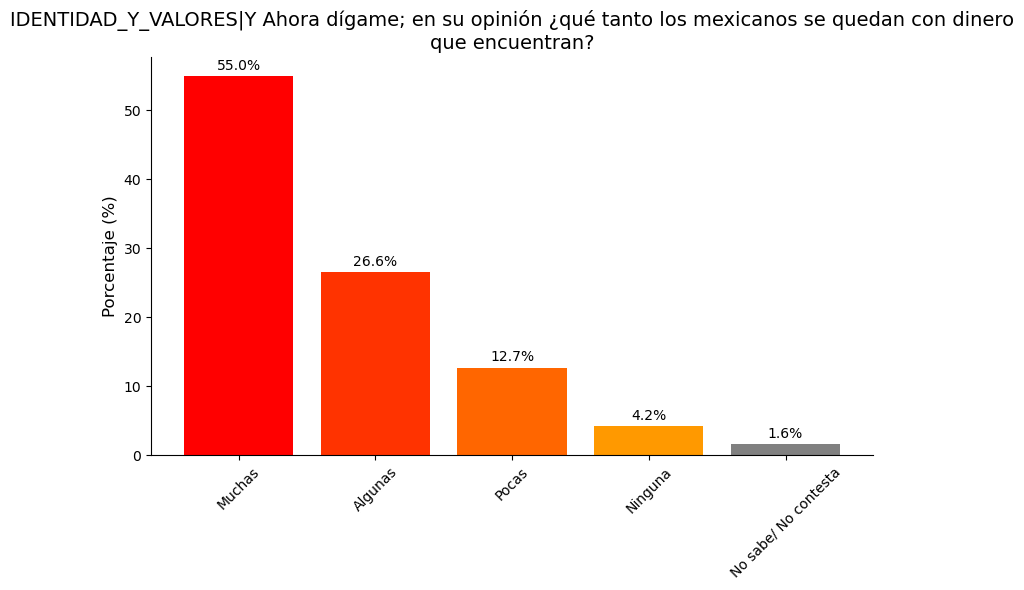

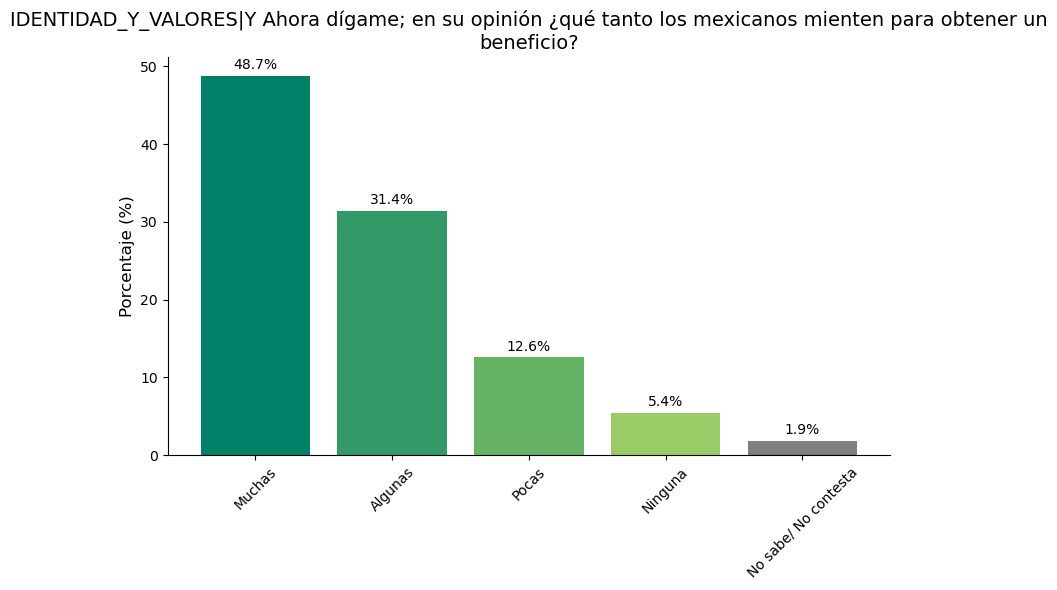

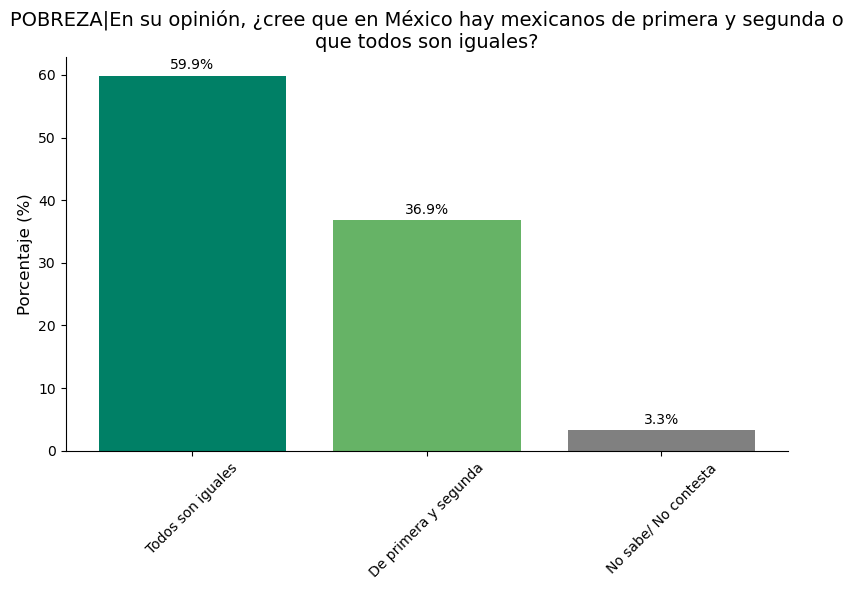

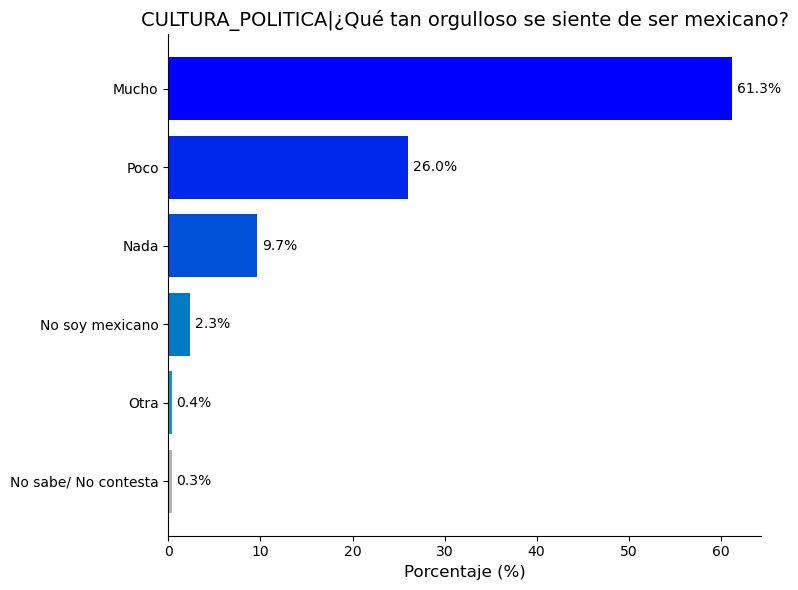

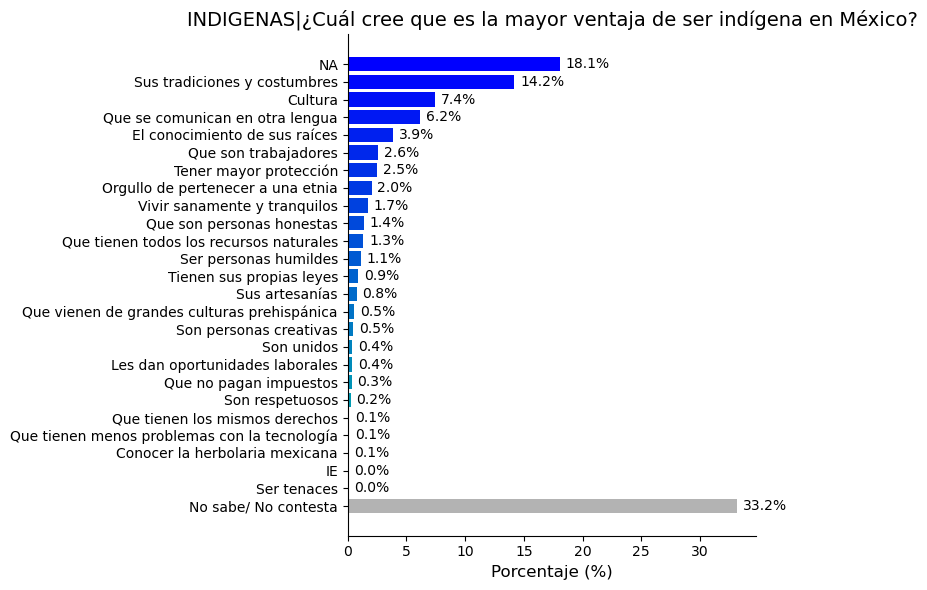

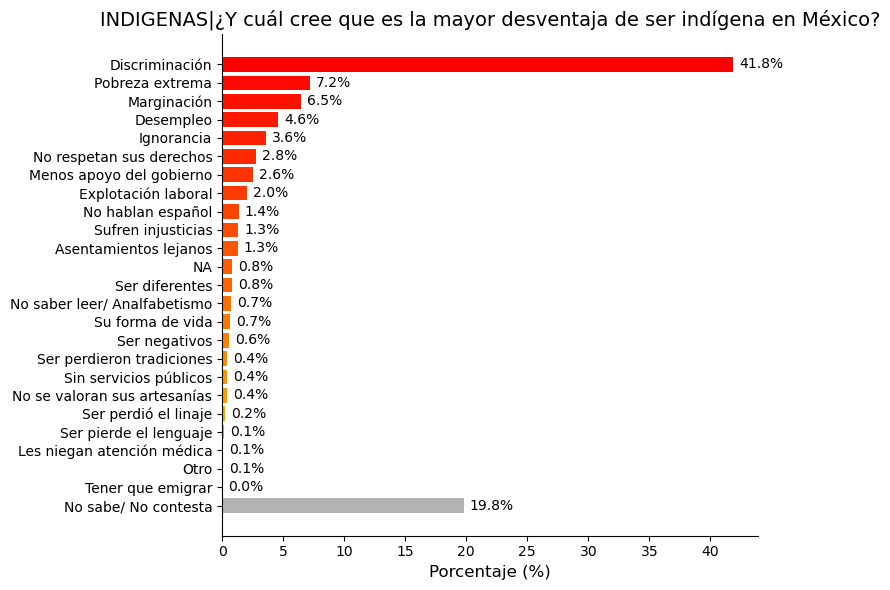

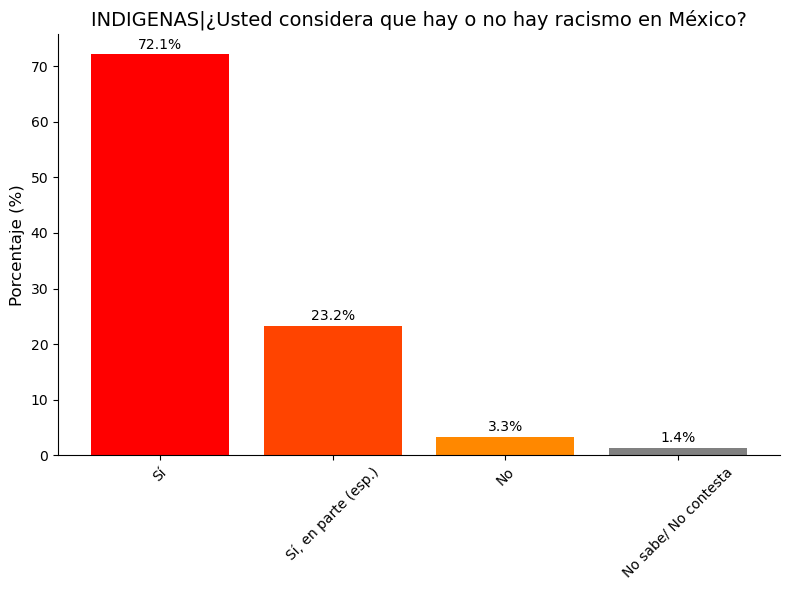

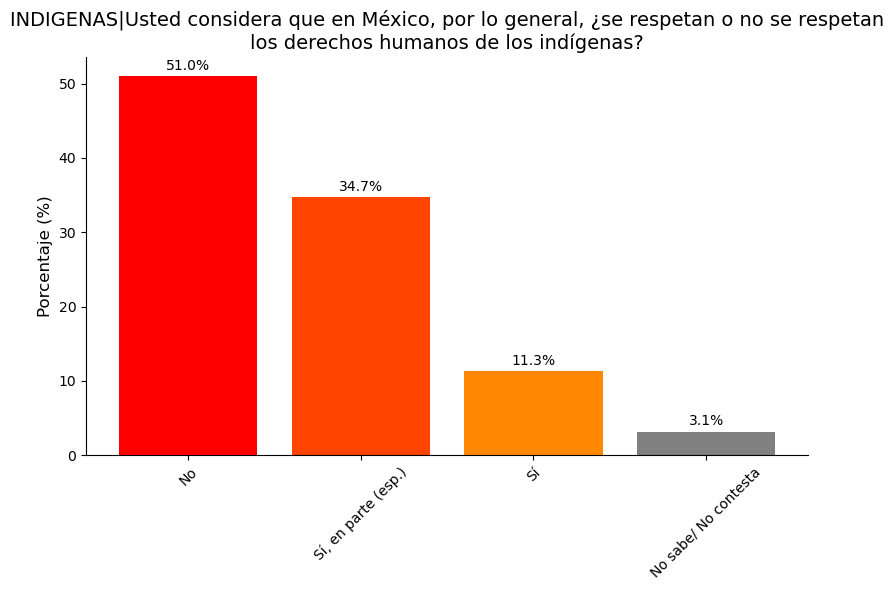

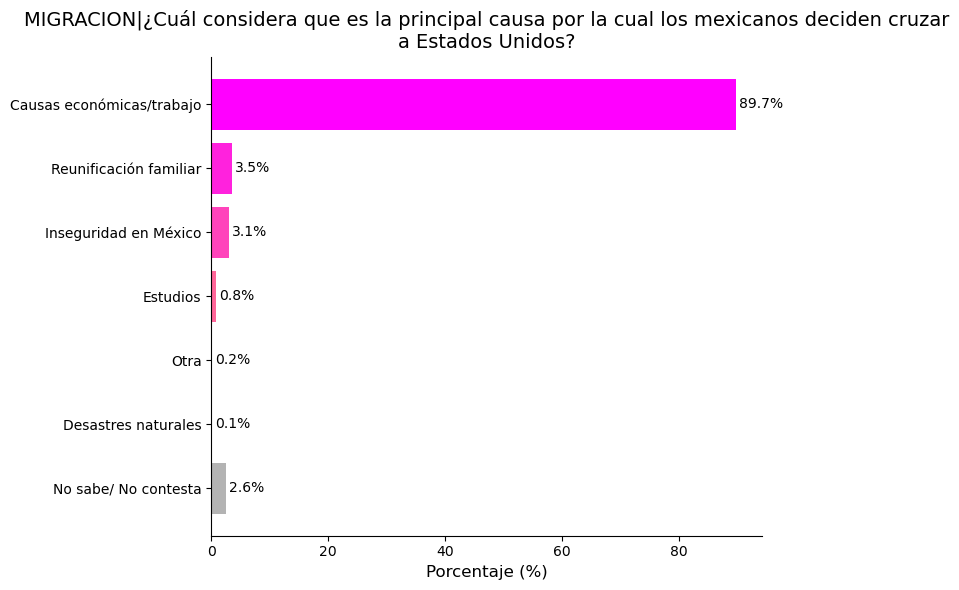

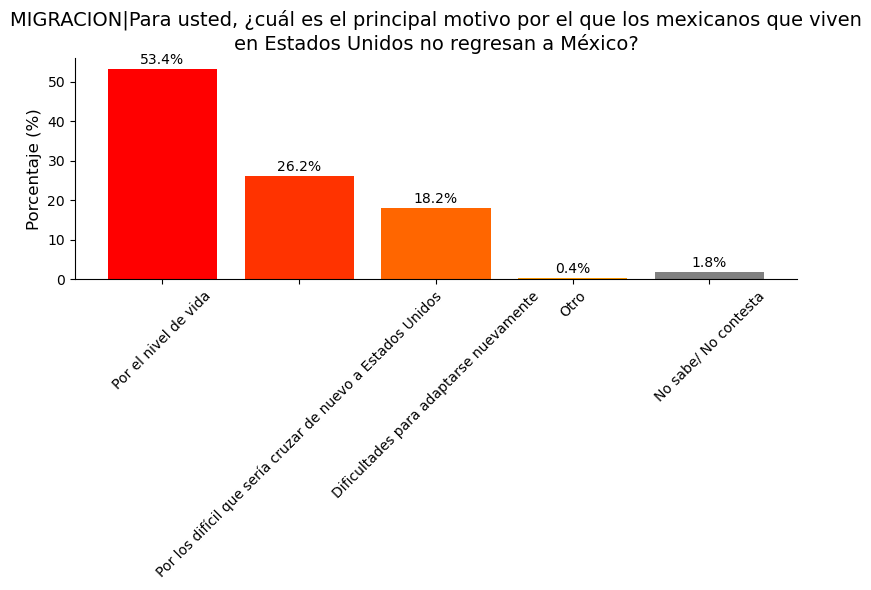

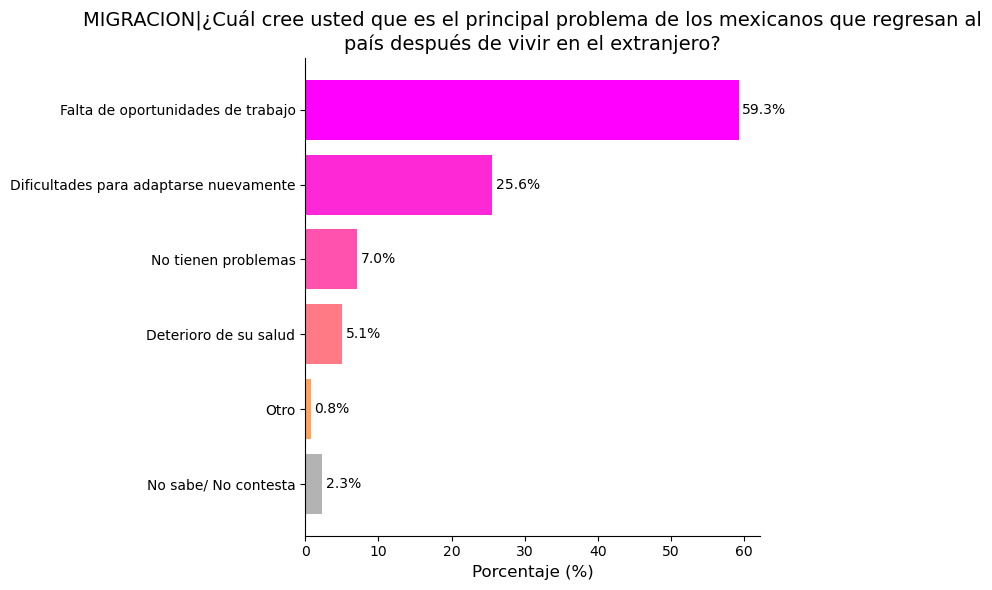

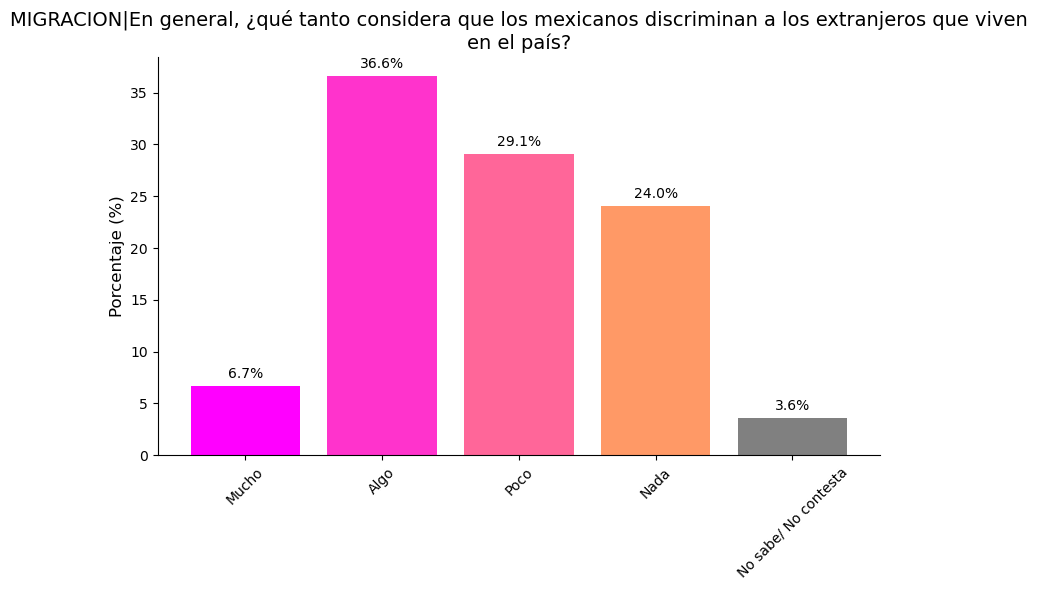

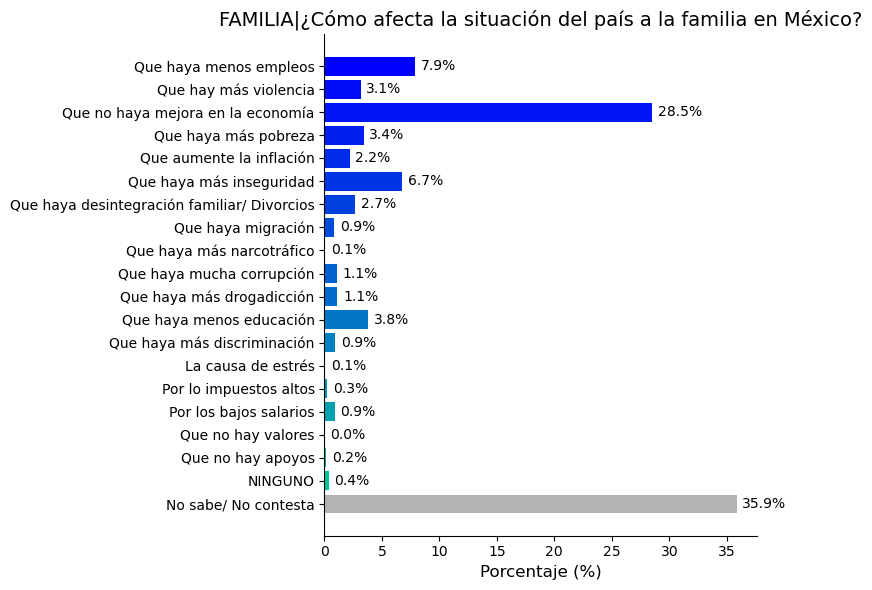

In [56]:
import numpy as np

import matplotlib.pyplot as plt

def split_text_by_words(text, n=14):
    """
    Splits a string into lines with a maximum of n words per line.

    Args:
        text (str): The input string to split.
        n (int): The maximum number of words per line.

    Returns:
        str: The formatted string with line breaks.
    """
    words = text.split()
    lines = [' '.join(words[i:i + n]) for i in range(0, len(words), n)]
    return '\n'.join(lines)

def create_plot(df, question, figsize=(6, 8)):
    """
    Creates a bar plot (horizontal if rows <= 6, vertical otherwise) of the survey data.

    Args:
        df (pd.DataFrame): DataFrame containing the data to plot.
        question (str): The survey question to use as the plot title.

    Returns:
        matplotlib.pyplot.figure: The matplotlib figure object.
    """
    # Determine plot type based on the number of rows
    if len(df) >= 6:
        # Horizontal bar plot
        fig, ax = plt.subplots(figsize=figsize)
        
        # Create a colormap where 'No sabe/ No contesta' is always gray

        colormaps = [plt.cm.summer, plt.cm.spring, plt.cm.winter, plt.cm.autumn]
        selected_colormap = np.random.choice(colormaps)
        colors = selected_colormap(np.linspace(0, 0.8, len(df)))

        if 'No sabe/ No contesta' in df.index:
            gray_index = list(df.index).index('No sabe/ No contesta')
            colors[gray_index] = [0.7, 0.7, 0.7, 1.0]  # RGBA for gray
        bars = ax.barh(df.index, df['%'], color=colors)

        # Add percentage labels to the bars
        for bar in bars:
            width = bar.get_width()
            label_position = width + 0.5  # Slightly to the right of the bar
            ax.text(label_position, bar.get_y() + bar.get_height()/2,
                    f'{width:.1f}%',
                    ha='left', va='center', fontsize=10)
                    # Apply split_text_by_words to tick labels for both axes
        # ax.set_yticklabels([split_text_by_words(label, n=3) for label in df.index], fontsize=10)
        # ax.set_xticklabels([split_text_by_words(str(label), n=3) for label in ax.get_xticks()], fontsize=10)
        # Customize plot
        ax.set_xlabel('Porcentaje (%)', fontsize=12)
        ax.set_title(split_text_by_words(question), fontsize=14)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Invert the y-axis to show the first item at the top
        ax.invert_yaxis()
        plt.tight_layout()

    else:
        # Vertical bar plot
        fig, ax = plt.subplots(figsize=figsize)

        colormaps = [plt.cm.summer, plt.cm.spring, plt.cm.winter, plt.cm.autumn]
        selected_colormap = np.random.choice(colormaps)
        colors = selected_colormap(np.linspace(0, 0.8, len(df)))
        
        if 'No sabe/ No contesta' in df.index:
            gray_index = list(df.index).index('No sabe/ No contesta')
            colors[gray_index] = [0.5, 0.5, 0.5, 1.0]  # RGBA for gray

        bars = ax.bar(df.index, df['%'], color=colors)

        # Add percentage labels above the bars
        for bar in bars:
            height = bar.get_height()
            label_position = height + 0.5
            ax.text(bar.get_x() + bar.get_width()/2, label_position,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=10)
        # ax.set_yticklabels([split_text_by_words(label, n=3) for label in df.index], fontsize=10)
        # ax.set_xticklabels([split_text_by_words(str(label), n=3) for label in ax.get_xticks()], fontsize=10)

        # Customize plot
        ax.set_ylabel('Porcentaje (%)', fontsize=12)
        ax.set_title(split_text_by_words(question), fontsize=14)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()

    return fig

# Example usage:
for key, df in tmp_df_dict.items():
    question = tmp_pregs_dict.get(key, 'Unknown Question')
    fig = create_plot(df, question, figsize=(8, 6))
    plt.show()  # Display each plot

In [ ]:
# TODO: crear markdown y pdf con resultados

In [122]:
from IPython.display import Markdown, display
from IPython.display import Image
from weasyprint import HTML

# title
query
# summary
answer_resumen.text
# recommendations
comments = {ky: tmp_sum_dict[ky]['answer'] for ky in tmp_sum_dict.keys()}
# plots
plots = {ky: create_plot(tmp_df_dict[ky], tmp_sel_dict[ky], figsize=(8, 6)) for ky in tmp_df_dict.keys()}

markdown_doc = f"# {query}\n\n"
markdown_doc += f"## Resumen\n\n{answer_resumen.text}\n\n"

# Add each comment followed by its plot
for ky in tmp_sum_dict.keys():
    markdown_doc += f"### {tmp_sel_dict[ky]}\n\n"
    markdown_doc += f"{comments[ky]}\n\n"
    # Save the plot as an image
    plot_path = f"plot_{ky}.png"
    # plots[ky].savefig(plot_path, format='png', bbox_inches='tight')
    plt.close(plots[ky])  # Close the plot to free up memory
    # Embed the image in the markdown
    markdown_doc += f"![Plot for {tmp_sel_dict[ky]}]({plot_path})\n\n"

# Display the markdown document
display(Markdown(markdown_doc))

import pypandoc

# If you already have your markdown string in `markdown_doc`:
output_pdf = "reporte.pdf"
pypandoc.convert_text(
    markdown_doc,
    to="pdf",
    format="md",
    outputfile=ruta_enc + output_pdf
)
print(f"Written {output_pdf}")


# qué es más importante para que la gente confíe en la ciencia?

## Resumen

El interés en la ciencia, la percepción de su contribución a la solución de problemas nacionales, la importancia que la gente le da al conocimiento científico, la facilidad para entender la información científica, la percepción de su accesibilidad, el fortalecimiento de la percepción positiva sobre la investigación en ciencias sociales, la generación de tecnología propia en México y el compromiso percibido de los científicos mexicanos con la sociedad son factores importantes para que la gente confíe en la ciencia.

Recomendamos que priorices la comunicación clara y accesible de la información científica, destacando la relevancia de la ciencia para resolver problemas nacionales y promoviendo la participación del público en actividades científicas. Deberías invertir en la divulgación científica a través de diversos medios, incluyendo la televisión, para llegar a un público más amplio. Además, es crucial fomentar una imagen positiva de la investigación en ciencias sociales y resaltar la capacidad de México para generar tecnología propia, lo que fortalecerá la confianza en la ciencia a nivel nacional. Finalmente, considera iniciativas que muestren el compromiso de los científicos con la sociedad, como proyectos de divulgación y participación ciudadana en la investigación.


### ¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?

El interés en la ciencia parece ser fundamental para construir la confianza pública en ella. Es probable que las personas con mayor interés en la ciencia estén más dispuestas a confiar en sus hallazgos y conclusiones.

![Plot for ¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?](plot_p11.png)

### ¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN

La gente que ve la televisión está más informada sobre ciencia, así que la ciencia debe invertir en ese medio para ganar confianza. Los científicos deben utilizar la televisión para comunicar mejor su investigación al público.

![Plot for ¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN](plot_p13_1.png)

### En su opinión ¿qué tan comprometidos están los científicos mexicanos con la sociedad?

Aunque la tabla evalúa el compromiso percibido de los científicos mexicanos con la sociedad, este compromiso podría influir en la confianza pública en la ciencia. Si la gente percibe que los científicos están comprometidos con la sociedad, es más probable que confíen en su trabajo y en los resultados de sus investigaciones, aumentando así la credibilidad de la ciencia en general.

![Plot for En su opinión ¿qué tan comprometidos están los científicos mexicanos con la sociedad?](plot_p33.png)

### Para usted, ¿qué tanto ha contribuido la ciencia mexicana  a solucionar los problemas del país?

La percepción de la contribución de la ciencia a la solución de problemas nacionales influye directamente en la confianza pública en la ciencia. Cuando la gente considera que la ciencia mexicana contribuye significativamente a resolver los problemas del país, es más probable que confíen en ella.

![Plot for Para usted, ¿qué tanto ha contribuido la ciencia mexicana  a solucionar los problemas del país?](plot_p34.png)

### ¿A usted le gustaría realizar actividades relacionadas con la ciencia?

Aunque esta tabla no pregunta directamente sobre la confianza en la ciencia, la disposición a participar en actividades científicas puede reflejar un nivel subyacente de confianza. Los resultados sugieren que aumentar la participación en actividades científicas podría ser una estrategia efectiva para fomentar la confianza en la ciencia, especialmente al convertir a aquellos que están indecisos en participantes activos.

![Plot for ¿A usted le gustaría realizar actividades relacionadas con la ciencia?](plot_p35.png)

### ¿Qué tan importante es para usted el conocimiento científico?

La importancia que la gente le da al conocimiento científico influye directamente en su confianza en la ciencia. Cuando una gran proporción de la población valora el conocimiento científico, es más probable que confíe en las conclusiones y avances que la ciencia ofrece.

![Plot for ¿Qué tan importante es para usted el conocimiento científico?](plot_p36.png)

### Dígame por favor, ¿qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos

La facilidad para entender la información científica es un factor clave para la confianza. Si las personas encuentran difícil comprender temas como los cultivos transgénicos, es probable que desconfíen de la ciencia detrás de ellos. Por lo tanto, mejorar la comunicación científica y hacerla más accesible es fundamental para fortalecer la confianza pública en la ciencia.

![Plot for Dígame por favor, ¿qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos](plot_p37_6.png)

### Ahora  dígame  por favor, ¿qué tan de acuerdo o desacuerdo está usted con los siguientes enunciados? La ciencia es demasiado especializada para que yo pueda entenderla

La confianza en la ciencia podría estar relacionada con la percepción de su accesibilidad. Si la gente siente que la ciencia es demasiado especializada y difícil de entender, es menos probable que confíe en ella. Por lo tanto, simplificar la ciencia y hacerla más accesible podría aumentar la confianza del público.

![Plot for Ahora  dígame  por favor, ¿qué tan de acuerdo o desacuerdo está usted con los siguientes enunciados? La ciencia es demasiado especializada para que yo pueda entenderla](plot_p45_1.png)

### Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Ciencias sociales

Para generar confianza en la ciencia, es crucial fortalecer la percepción positiva sobre la investigación en ciencias sociales. Reducir la proporción de personas con poca o ninguna confianza, así como el porcentaje de quienes no saben o no contestan, mediante una mayor divulgación y transparencia en los procesos de investigación, podría ser fundamental para fomentar la credibilidad científica.

![Plot for Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Ciencias sociales](plot_p50_4.png)

### ¿Qué tan importante es para México generar tecnología propia?

La generación de tecnología propia en México impulsa la confianza en la ciencia al demostrar la capacidad del país para innovar y resolver problemas locales. Al generar tecnología propia, se fomenta una cultura científica y se empodera a los investigadores mexicanos, lo que a su vez fortalece la credibilidad de la ciencia ante la población.

![Plot for ¿Qué tan importante es para México generar tecnología propia?](plot_p52.png)



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Written reporte.pdf


In [108]:
plots

{'p11': <Figure size 800x600 with 1 Axes>,
 'p13_1': <Figure size 800x600 with 1 Axes>,
 'p33': <Figure size 800x600 with 1 Axes>,
 'p34': <Figure size 800x600 with 1 Axes>,
 'p35': <Figure size 800x600 with 1 Axes>,
 'p36': <Figure size 800x600 with 1 Axes>,
 'p37_6': <Figure size 800x600 with 1 Axes>,
 'p45_1': <Figure size 800x600 with 1 Axes>,
 'p50_4': <Figure size 800x600 with 1 Axes>,
 'p52': <Figure size 800x600 with 1 Axes>}

In [134]:
# prompt para gráficos 

def create_prompt_plot(query, table_key, tmp_markdown_tables):
    """
    Creates a prompt for analyzing a table and answering a query.

    Parameters:
        query (str): The query to be answered.
        table_key (str): The key of the table to be analyzed.
        tmp_markdown_tables (dict): A dictionary containing markdown tables.
        tmp_nsnc_val (str): The threshold percentage for 'No sabe/ No contesta'.

    Returns:
        str: The generated prompt.
    """
    tmp_tab_st = tmp_markdown_tables[table_key]

    prompt = f"""
    You are a very proficient python coder working on a survey research project, and an expert creative in data visualization and infographics.
    You are fully bilingual in English and Spanish, and can do its work in either language. 

    Your task is to take each of the following steps in sequence and make sure to follow up the results of each step with your work on the next one.

    1) analyze a TABLE containing the results of a survey. Note that the HEADER of the TABLE contains the question, the FIRST COLUMN contains the answer options, and the SECOND COLUMN contains the percentage of people that selected that answered each option.
    Based on your analysis of the table, you will create a plot that best represents the data in the table. Make the plot informative and visually appealing, but simple. 
    - think about the type of variable in the plot: it may be a scale, that contain qualifiers like 'mucho' or 'a lot' to 'nada' or 'nothing', or 'muy de acuerdo' or 'agree a lot' to 'nada de acuerdo' or 'not at all agree'.
    - also think about 'no sabe/ no contesta' or 'no answer/ does not know' option, and note that it will require special treatment in the plot.
    - think about the type of plot that best represents the data in the table, and how to make it visually appealing.
    
    Now, write a short description of the plot you are going to create, and the motivation behind your design.

    2) create a PLOT OBJECT in python that best represents the data in the table.

    The PLOT OBJECT should be a python code that generates the plot you designed in the first step.
    The plot should be a high-quality plot that is suitable for publication. It should be clear, easy to read, and visually appealing.
    The plot should include the following elements:
    - Use the viridis color map for every plot, unless for 'No sabe/ No contesta' should always be plotted in '#A9A9A9'.
    - Use horizontal bar plots and make sure that 'No sabe/ No contesta' is always at the bottom of the plot.
    - make sure to remove the top and right spines of the plot.
    - All elements of the plot should be in the same language as the query.

    The PLOT OBJECT should be the code to produce the plot of your design, using matplotlib, and it should retrun the plot object only. 
    Prioritize the correctness of the code over the aesthetics of the plot to make sure it runs correctly. Pay particular attention to the parameters required to assign colors, and betweeen the difference of c to color in hexbin and color as string names in matplotlib.

    This PLOT OBJECT returned should be the markdown version of the code chunck, so it can be either displayed or parsed for execution.

    3) review the code to make sure it works correctly, and revise it if necessary.

    4) You will only return a python dict called tmp_plot_res_dict[{table_key}], containaing the code as a string without markdown markers. 
    Do not initialize tmp_plot_res_dict because it will be initialized before execution of the code. 
    Make sure to add your reasoning ONLY to the code as comments, your answer should be only the code, ready to be parsed and executed. 
    Make sure to omit any markers like ```python or ```python, and do not include any other text in the answer.

    Try removing the triple quotes or placing them consistently to avoid string parsing errors. 
    Also consider returning only the code needed rather than the entire multiline string. 
    Make sure tmp_agg_out_lst is assigned valid Python code (without partial quotes or mismatched indentation) that can be executed directly.

    QUERY: {query}

    TABLE: {tmp_tab_st}
    """
    return prompt

# Example usage:
prompt = create_prompt_plot(query, 'p13_1', tmp_markdown_tables)


tmp_pmt_lst= [create_prompt_plot(query, ky_st, tmp_markdown_tables) for ky_st in tmp_markdown_tables.keys()]


# Define the configuration with lower temperature
model_config = types.GenerateContentConfig(
    temperature=0.0,
)

# Process each prompt individually
answers = {}
for i, prompt in enumerate(tmp_pmt_lst):
    print(f'generating answer for prompt {i+1}/{len(tmp_pmt_lst)}')
    key = list(tmp_markdown_tables.keys())[i] # Get the original key for this prompt
    answer = client.models.generate_content(
        model="gemini-2.0-flash",
        config=model_config,
        contents=prompt)
    answers[key] = answer # Store answer using the original key

tmp_ans_lst = [answers[ky].text.replace('tmp_plot_res_dict = {}\n', '') for ky in answers.keys()]
tmp_agg_ans_lst = [ans_st.strip("```python").replace("```", '\n').replace('python', '') for ans_st in tmp_ans_lst]
tmp_agg_out_lst = ''.join(tmp_agg_ans_lst)

import ast

# Validate and execute the generated code
def validate_and_execute(code_str):
    try:
        # Parse the code to ensure it is valid Python
        parsed_code = ast.parse(code_str)
        exec(compile(parsed_code, filename="<string>", mode="exec"))
    except Exception as e:
        print(f"Error in generated code: {e}")
        return None

validate_and_execute(tmp_agg_out_lst)

generating answer for prompt 1/9
generating answer for prompt 2/9
generating answer for prompt 3/9
generating answer for prompt 4/9
generating answer for prompt 5/9
generating answer for prompt 6/9
generating answer for prompt 7/9
generating answer for prompt 8/9
generating answer for prompt 9/9
Error in generated code: Unknown engine:  (valid options are dict_keys(['c', 'python', 'pyarrow', 'python-fwf']))


In [135]:
print(tmp_agg_out_lst)


# Define the data from the table
answers = ['Poco', 'Algo', 'Nada', 'Mucho', 'No sabe/ No contesta']
percentages = [37.4, 29.5, 21.7, 10.4, 1.0]

# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# Define the plot function
def create_plot(answers, percentages):
    """
    Creates a horizontal bar plot of the survey data.

    Args:
        answers (list): List of answer options.
        percentages (list): List of percentages corresponding to each answer.

    Returns:
        matplotlib.pyplot.figure: The matplotlib figure object.
    """

    # Ensure the 'No sabe/ No contesta' is at the bottom
    if 'No sabe/ No contesta' in answers:
        no_answer_index = answers.index('No sabe/ No contesta')
        answers.append(answers.pop(no_answer_index))
        percentages.append(percentages.pop(no_answer_index))

    # Define colors
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(answers) - 1))  # viridis colormap
    bar_colors = 

In [ ]:
# Define the data from the table
answers = ['Poco', 'Algo', 'Nada', 'Mucho', 'No sabe/ No contesta']
percentages = [37.4, 29.5, 21.7, 10.4, 1.0]

# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# Define the plot function
def create_plot(answers, percentages):
    """
    Creates a horizontal bar plot of the survey data.

    Args:
        answers (list): List of answer options.
        percentages (list): List of percentages corresponding to each answer.

    Returns:
        matplotlib.pyplot.figure: The matplotlib figure object.
    """

    # Ensure the 'No sabe/ No contesta' is at the bottom
    if 'No sabe/ No contesta' in answers:
        no_answer_index = answers.index('No sabe/ No contesta')
        answers.append(answers.pop(no_answer_index))
        percentages.append(percentages.pop(no_answer_index))

    # Define colors
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(answers) - 1))  # viridis colormap
    bar_colors = list(colors)
    bar_colors.append('#A9A9A9')  # Grey for 'No sabe/ No contesta'

    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size for better readability

    # Create horizontal bars
    ax.barh(answers, percentages, color=bar_colors)

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add labels and title
    ax.set_xlabel('Porcentaje (%)', fontsize=12)
    ax.set_title('¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?', fontsize=14)

    # Adjust x-axis limits
    ax.set_xlim(0, max(percentages) + 5)  # Add some padding to the right

    # Add percentage labels to the bars
    for i, v in enumerate(percentages):
        ax.text(v + 1, i, str(v) + '%', color='black', va='center', fontsize=10)

    # Invert the y-axis to show the first item at the top
    ax.invert_yaxis()

    # Adjust layout to prevent labels from overlapping
    plt.tight_layout()

    return fig

# Create the plot object
fig = create_plot(answers, percentages)

# Convert the plot to a string representation
# # tmp_plot_res_dict['p11'] = '''
# import matplotlib.pyplot as plt
# import numpy as np
# import matplotlib

# # Define the data from the table
# answers = ['Poco', 'Algo', 'Nada', 'Mucho', 'No sabe/ No contesta']
# percentages = [37.4, 29.5, 21.7, 10.4, 1.0]

# # Define the plot function
# def create_plot(answers, percentages):
#     """
#     Creates a horizontal bar plot of the survey data.

#     Args:
#         answers (list): List of answer options.
#         percentages (list): List of percentages corresponding to each answer.

#     Returns:
#         matplotlib.pyplot.figure: The matplotlib figure object.
#     """

#     # Ensure the 'No sabe/ No contesta' is at the bottom
#     if 'No sabe/ No contesta' in answers:
#         no_answer_index = answers.index('No sabe/ No contesta')
#         answers.append(answers.pop(no_answer_index))
#         percentages.append(percentages.pop(no_answer_index))

#     # Define colors
#     colors = plt.cm.viridis(np.linspace(0, 0.8, len(answers) - 1))  # viridis colormap
#     bar_colors = list(colors)
#     bar_colors.append('#A9A9A9')  # Grey for 'No sabe/ No contesta'

#     # Create the plot
#     fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size for better readability

#     # Create horizontal bars
#     ax.barh(answers, percentages, color=bar_colors)

#     # Remove top and right spines
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

#     # Add labels and title
#     ax.set_xlabel('Porcentaje (%)', fontsize=12)
#     ax.set_title('¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?', fontsize=14)

#     # Adjust x-axis limits
#     ax.set_xlim(0, max(percentages) + 5)  # Add some padding to the right

#     # Add percentage labels to the bars
#     for i, v in enumerate(percentages):
#         ax.text(v + 1, i, str(v) + '%', color='black', va='center', fontsize=10)

#     # Invert the y-axis to show the first item at the top
#     ax.invert_yaxis()

#     # Adjust layout to prevent labels from overlapping
#     plt.tight_layout()

#     return fig

# # Create the plot object
# fig = create_plot(answers, percentages)
# '''
tmp_plot_res_dict['p11'] = """import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# Define the data from the table
answers = ['Poco', 'Algo', 'Nada', 'Mucho', 'No sabe/ No contesta']
percentages = [37.4, 29.5, 21.7, 10.4, 1.0]

# Define the plot function
def create_plot(answers, percentages):
    # Ensure the 'No sabe/ No contesta' is at the bottom
    if 'No sabe/ No contesta' in answers:
        no_answer_index = answers.index('No sabe/ No contesta')
        answers.append(answers.pop(no_answer_index))
        percentages.append(percentages.pop(no_answer_index))

    # Define colors
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(answers) - 1))  # viridis colormap
    bar_colors = list(colors)
    bar_colors.append('#A9A9A9')  # Grey for 'No sabe/ No contesta'

    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size for better readability

    # Create horizontal bars
    ax.barh(answers, percentages, color=bar_colors)

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add labels and title
    ax.set_xlabel('Porcentaje (%)', fontsize=12)
    ax.set_title('¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?', fontsize=14)

    # Adjust x-axis limits
    ax.set_xlim(0, max(percentages) + 5)  # Add some padding to the right

    # Add percentage labels to the bars
    for i, v in enumerate(percentages):
        ax.text(v + 1, i, str(v) + '%', color='black', va='center', fontsize=10)

    # Invert the y-axis to show the first item at the top
    ax.invert_yaxis()

    # Adjust layout to prevent labels from overlapping
    plt.tight_layout()

    return fig

# Create the plot object
fig = create_plot(answers, percentages)
"""

# Analyzing the table:
# The table shows the percentage of people who get their science news from different sources.
# The variable is categorical, with options like "Television", "Internet", "Newspaper", etc.
# "No sabe/ No contesta" is present and needs special handling.
# A horizontal bar plot is suitable for visualizing this data, with bars representing each source and their length representing the percentage.
# "No sabe/ No contesta" will be placed at the bottom and colored in grey.

# Creating the plot object:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import io

# Data provided in the prompt
data = {
    '¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN': [
        'Por la televisión',
        'Nunca me informo',
        'Por internet',
        'Por el periódico',
        'Por la radio',
        'Por amigos',
        'Redes sociales (Facebook, twitter)',
        'Por la familia',
        'No sabe/ No contesta',
        'Por vecinos',
        'Por revistas de divulgación',
        'Otro'
    ],
    '%': [50.2, 16.8, 11.9, 9.7, 3.2, 2.2, 1.5, 1.0, 1.8, 0.8, 0.4, 0.4]
}

df = pd.DataFrame(data)

# Ensure the percentages are numeric
df['%'] = pd.to_numeric(df['%'])

# Move "No sabe/ No contesta" to the end
no_sabe = df[df['¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN'] == 'No sabe/ No contesta']
df = df[df['¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN'] != 'No sabe/ No contesta']
df = pd.concat([df, no_sabe], ignore_index=True)

# Define colors: viridis for the sources, grey for "No sabe/ No contesta"
colors = plt.cm.viridis(np.linspace(0, 0.8, len(df) - 1)).tolist()
colors.append('#A9A9A9')  # Grey for "No sabe/ No contesta"

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar plot
ax.barh(df['¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN'], df['%'], color=colors)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add labels and title
ax.set_xlabel('Porcentaje', fontsize=12)
ax.set_title('¿Cómo se informa principalmente sobre noticias de ciencia?', fontsize=14)

# Invert the y-axis to have the first item at the top
ax.invert_yaxis()

# Add percentage labels to the bars
for i, v in enumerate(df['%']):
    ax.text(v + 0.5, i, str(v) + '%', color='black', va='center')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Return the plot object
tmp_plot_res_dict['p13_1'] = """
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import io

# Data provided in the prompt
data = {
    '¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN': [
        'Por la televisión',
        'Nunca me informo',
        'Por internet',
        'Por el periódico',
        'Por la radio',
        'Por amigos',
        'Redes sociales (Facebook, twitter)',
        'Por la familia',
        'No sabe/ No contesta',
        'Por vecinos',
        'Por revistas de divulgación',
        'Otro'
    ],
    '%': [50.2, 16.8, 11.9, 9.7, 3.2, 2.2, 1.5, 1.0, 1.8, 0.8, 0.4, 0.4]
}

df = pd.DataFrame(data)

# Ensure the percentages are numeric
df['%'] = pd.to_numeric(df['%'])

# Move "No sabe/ No contesta" to the end
no_sabe = df[df['¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN'] == 'No sabe/ No contesta']
df = df[df['¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN'] != 'No sabe/ No contesta']
df = pd.concat([df, no_sabe], ignore_index=True)

# Define colors: viridis for the sources, grey for "No sabe/ No contesta"
colors = plt.cm.viridis(np.linspace(0, 0.8, len(df) - 1)).tolist()
colors.append('#A9A9A9')  # Grey for "No sabe/ No contesta"

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar plot
ax.barh(df['¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN'], df['%'], color=colors)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add labels and title
ax.set_xlabel('Porcentaje', fontsize=12)
ax.set_title('¿Cómo se informa principalmente sobre noticias de ciencia?', fontsize=14)

# Invert the y-axis to have the first item at the top
ax.invert_yaxis()

# Add percentage labels to the bars
for i, v in enumerate(df['%']):
    ax.text(v + 0.5, i, str(v) + '%', color='black', va='center')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

plt.show()
"""

# Analyzing the table:
# The question is about the level of commitment of Mexican scientists to society.
# The answers are on a scale from "Nada" (Nothing) to "Mucho" (A lot), with a "No sabe/ No contesta" (Don't know/No answer) option.
# A horizontal bar plot is suitable for this data, as it allows for easy comparison of the percentages for each level of commitment.
# The "No sabe/ No contesta" option will be placed at the bottom of the plot and colored in grey.

# Creating the plot object:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data from the table
data = {'Compromiso': ['Algo', 'Mucho', 'Poco', 'Nada', 'No sabe/ No contesta'],
        'Porcentaje': [44.1, 23.3, 18.8, 4.1, 9.7]}
df = pd.DataFrame(data)

# Sort the DataFrame to put 'No sabe/ No contesta' at the bottom
df = df.sort_values(by='Compromiso', key=lambda x: x == 'No sabe/ No contesta')

# Colors: viridis for the scale, grey for 'No sabe/ No contesta'
colors = ['#A9A9A9' if x == 'No sabe/ No contesta' else plt.cm.viridis(i/float(len(df)-1)) for i, x in enumerate(df['Compromiso'])]

# Creating the plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df['Compromiso'], df['Porcentaje'], color=colors)

# Removing top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adding labels and title
ax.set_xlabel('Porcentaje', fontsize=12)
ax.set_ylabel('Compromiso', fontsize=12)
ax.set_title('¿Qué tan comprometidos están los científicos mexicanos con la sociedad?', fontsize=14)

# Adding percentage labels to the bars
for bar in bars:
    width = bar.get_width()
    label_position = width + 0.5  # Slightly to the right of the bar
    ax.text(label_position, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%',
            ha='left', va='center', fontsize=10)

# Adjusting layout to prevent labels from being cut off
plt.tight_layout()

# Return the plot object
tmp_plot_res_dict['p33'] = """
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data from the table
data = {'Compromiso': ['Algo', 'Mucho', 'Poco', 'Nada', 'No sabe/ No contesta'],
        'Porcentaje': [44.1, 23.3, 18.8, 4.1, 9.7]}
df = pd.DataFrame(data)

# Sort the DataFrame to put 'No sabe/ No contesta' at the bottom
df = df.sort_values(by='Compromiso', key=lambda x: x == 'No sabe/ No contesta')

# Colors: viridis for the scale, grey for 'No sabe/ No contesta'
colors = ['#A9A9A9' if x == 'No sabe/ No contesta' else plt.cm.viridis(i/float(len(df)-1)) for i, x in enumerate(df['Compromiso'])]

# Creating the plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df['Compromiso'], df['Porcentaje'], color=colors)

# Removing top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adding labels and title
ax.set_xlabel('Porcentaje', fontsize=12)
ax.set_ylabel('Compromiso', fontsize=12)
ax.set_title('¿Qué tan comprometidos están los científicos mexicanos con la sociedad?', fontsize=14)

# Adding percentage labels to the bars
for bar in bars:
    width = bar.get_width()
    label_position = width + 0.5  # Slightly to the right of the bar
    ax.text(label_position, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%',
            ha='left', va='center', fontsize=10)

# Adjusting layout to prevent labels from being cut off
plt.tight_layout()

plt.show()
"""

# Define the dictionary to store the plot code

# Analyze the table and determine the best plot type
# The data represents the distribution of opinions on the contribution of Mexican science to solving the country's problems.
# A horizontal bar plot is suitable for visualizing this type of data, as it allows for easy comparison of the percentages for each category.
# The 'No sabe/ No contesta' category will be placed at the bottom of the plot and colored in grey.

# Create the plot object in Python
tmp_agg_out_lst = """
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# Data from the table
categories = ['Nada', 'Poco', 'Algo', 'Mucho', 'No sabe/ No contesta']
percentages = [9.1, 25.8, 39.8, 15.3, 10.0]

# Sort categories and percentages, placing 'No sabe/ No contesta' at the end
categories, percentages = zip(*sorted(zip(categories, percentages), key=lambda x: x[0] != 'No sabe/ No contesta'))
categories = list(categories)
percentages = list(percentages)

# Colors for the bars, using viridis colormap and grey for 'No sabe/ No contesta'
colors = matplotlib.colormaps['viridis'](np.linspace(0, 0.7, len(categories)-1)).tolist()
colors.append('#A9A9A9') # Grey color for 'No sabe/ No contesta'

# Create the horizontal bar plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(categories, percentages, color=colors)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add percentage labels to the bars
for bar in bars:
    width = bar.get_width()
    label_x_pos = width + 1 # Position the label slightly to the right of the bar
    ax.text(label_x_pos, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
            ha='left', va='center', color='black')

# Set plot title and labels
ax.set_xlabel('Porcentaje')
ax.set_title('¿Qué tanto ha contribuido la ciencia mexicana a solucionar los problemas del país?')

# Invert the y-axis to have 'No sabe/ No contesta' at the bottom
ax.invert_yaxis()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Return the plot object
plt
"""

# Store the plot code in the dictionary
tmp_plot_res_dict['p34'] = tmp_agg_out_lst

# Analyze the table and determine the best plot type.
# The data represents the importance of scientific knowledge, which is an ordinal scale.
# A horizontal bar plot is suitable for visualizing the percentages for each category.
# The 'No sabe/ No contesta' category will be placed at the bottom and colored differently.

# Description of the plot:
# A horizontal bar plot showing the percentage of people who selected each answer option.
# The bars are ordered from 'Muy importante' to 'Nada importante', with 'No sabe/ No contesta' at the bottom.
# The bars are colored using the viridis colormap, except for 'No sabe/ No contesta', which is gray.
# The plot includes labels for each bar and the percentage values.
# The top and right spines are removed for a cleaner look.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data from the table
data = {
    'Respuesta': ['Algo Importante', 'Muy importante', 'Poco importante', 'Nada importante', 'No sabe/ No contesta'],
    'Porcentaje': [41.1, 28.3, 18.8, 8.2, 3.6]
}
df = pd.DataFrame(data)

# Order the DataFrame as desired
order = ['Muy importante', 'Algo Importante', 'Poco importante', 'Nada importante', 'No sabe/ No contesta']
df['Respuesta'] = pd.Categorical(df['Respuesta'], categories=order, ordered=True)
df = df.sort_values('Respuesta')

# Colors
colors = plt.cm.viridis(np.linspace(0, 1, len(df) - 1))
color_nsnc = '#A9A9A9'  # Gray color for 'No sabe/ No contesta'
colors = np.append(colors, color_nsnc)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(df['Respuesta'], df['Porcentaje'], color=colors)

# Add percentage labels
for i, v in enumerate(df['Porcentaje']):
    ax.text(v + 1, i, str(v) + '%', color='black', va='center')

# Customize plot
ax.set_xlabel('Porcentaje')
ax.set_title('¿Qué es más importante para que la gente confíe en la ciencia?')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Return the plot object
tmp_plot_res_dict['p36'] = """
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data from the table
data = {
    'Respuesta': ['Algo Importante', 'Muy importante', 'Poco importante', 'Nada importante', 'No sabe/ No contesta'],
    'Porcentaje': [41.1, 28.3, 18.8, 8.2, 3.6]
}
df = pd.DataFrame(data)

# Order the DataFrame as desired
order = ['Muy importante', 'Algo Importante', 'Poco importante', 'Nada importante', 'No sabe/ No contesta']
df['Respuesta'] = pd.Categorical(df['Respuesta'], categories=order, ordered=True)
df = df.sort_values('Respuesta')

# Colors
colors = plt.cm.viridis(np.linspace(0, 1, len(df) - 1))
color_nsnc = '#A9A9A9'  # Gray color for 'No sabe/ No contesta'
colors = np.append(colors, color_nsnc)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(df['Respuesta'], df['Porcentaje'], color=colors)

# Add percentage labels
for i, v in enumerate(df['Porcentaje']):
    ax.text(v + 1, i, str(v) + '%', color='black', va='center')

# Customize plot
ax.set_xlabel('Porcentaje')
ax.set_title('¿Qué es más importante para que la gente confíe en la ciencia?')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
"""

# Define the plot description
# We will create a horizontal bar plot to represent the survey data.
# The x-axis will represent the percentage of respondents, and the y-axis will represent the answer options.
# The 'No sabe/ No contesta' option will be placed at the bottom of the plot and colored in grey.
# The other options will be colored using the viridis colormap.
# The plot will have a clean and simple design, with the top and right spines removed.
# All elements of the plot will be in Spanish.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import io

# Define the data from the table
data = """
| Dígame por favor, ¿qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos   |    % |
|:--------------------------------------------------------------------------------------------------------------------------------------|-----:|
| Difícil                                                                                                                               | 31.0 |
| Ni fácil ni difícil                                                                                                                   | 23.6 |
| Fácil                                                                                                                                 | 17.4 |
| Muy difícil                                                                                                                           | 16.2 |
| Muy fácil                                                                                                                             |  4.1 |
| No sabe/ No contesta                                                                                                                  |  7.7 |
"""

# Read the data into a pandas DataFrame
df = pd.read_csv(io.StringIO(data), sep='|', engine='', skipinitialspace=True).iloc[1:]
df.columns = [col.strip() for col in df.columns]
df = df.rename(columns={df.columns[1]: 'Percentage', df.columns[0]: 'Answer'})
df['Percentage'] = df['Percentage'].str.strip().astype(float)
df['Answer'] = df['Answer'].str.strip()

# Reorder the DataFrame to put 'No sabe/ No contesta' at the bottom
no_sabe = df[df['Answer'] == 'No sabe/ No contesta']
df = df[df['Answer'] != 'No sabe/ No contesta']
df = pd.concat([df, no_sabe], ignore_index=True)

# Define the colors for the bars
colors = plt.cm.viridis(np.linspace(0, 0.8, len(df) - 1)) # Use viridis colormap
color_list = list(colors)
color_list.append('#A9A9A9') # Grey for 'No sabe/ No contesta'
colors = color_list

# Create the horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df['Answer'], df['Percentage'], color=colors)

# Set the title and labels
ax.set_xlabel('Porcentaje (%)')
ax.set_title('¿Qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos')

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Invert the y-axis to have the first item at the top
ax.invert_yaxis()

# Add percentage labels to the bars
for i, v in enumerate(df['Percentage']):
    ax.text(v + 1, i, str(v) + '%', color='black', va='center')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Return the plot object
tmp_plot_res_dict['p37_6'] = """
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import io

# Define the data from the table
data = \"\"\"
| Dígame por favor, ¿qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos   |    % |
|:--------------------------------------------------------------------------------------------------------------------------------------|-----:|
| Difícil                                                                                                                               | 31.0 |
| Ni fácil ni difícil                                                                                                                   | 23.6 |
| Fácil                                                                                                                                 | 17.4 |
| Muy difícil                                                                                                                           | 16.2 |
| Muy fácil                                                                                                                             |  4.1 |
| No sabe/ No contesta                                                                                                                  |  7.7 |
\"\"\"

# Read the data into a pandas DataFrame
df = pd.read_csv(io.StringIO(data), sep='|', engine='', skipinitialspace=True).iloc[1:]
df.columns = [col.strip() for col in df.columns]
df = df.rename(columns={df.columns[1]: 'Percentage', df.columns[0]: 'Answer'})
df['Percentage'] = df['Percentage'].str.strip().astype(float)
df['Answer'] = df['Answer'].str.strip()

# Reorder the DataFrame to put 'No sabe/ No contesta' at the bottom
no_sabe = df[df['Answer'] == 'No sabe/ No contesta']
df = df[df['Answer'] != 'No sabe/ No contesta']
df = pd.concat([df, no_sabe], ignore_index=True)

# Define the colors for the bars
colors = plt.cm.viridis(np.linspace(0, 0.8, len(df) - 1)) # Use viridis colormap
color_list = list(colors)
color_list.append('#A9A9A9') # Grey for 'No sabe/ No contesta'
colors = color_list

# Create the horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df['Answer'], df['Percentage'], color=colors)

# Set the title and labels
ax.set_xlabel('Porcentaje (%)')
ax.set_title('¿Qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos')

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Invert the y-axis to have the first item at the top
ax.invert_yaxis()

# Add percentage labels to the bars
for i, v in enumerate(df['Percentage']):
    ax.text(v + 1, i, str(v) + '%', color='black', va='center')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Return the plot object
plt
"""

# This code generates a horizontal bar plot to visualize survey responses.
# The plot displays the percentage of respondents for each agreement level,
# with 'No sabe/ No contesta' at the bottom and a grey color.
# Viridis colormap is used for the other categories.

import matplotlib.pyplot as plt
import numpy as np

# Data from the table
categories = ['Parcialmente de acuerdo', 'Totalmente de acuerdo', 'Ni de acuerdo ni desacuerdo',
              'Parcialmente en desacuerdo', 'Totalmente en desacuerdo', 'No sabe/ No contesta']
percentages = [30.7, 25.7, 21.8, 9.2, 8.6, 4.1]

# Define colors, using viridis for agreement levels and grey for 'No sabe/ No contesta'
colors = plt.cm.viridis(np.linspace(0, 0.7, len(categories) - 1)).tolist() # Use a subset of viridis
colors.append('#A9A9A9')  # Grey color for 'No sabe/ No contesta'

# Reorder categories and percentages to put 'No sabe/ No contesta' at the bottom
categories = categories[:-1] + [categories[-1]]
percentages = percentages[:-1] + [percentages[-1]]
colors = colors[:-1] + [colors[-1]]

# Create the horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(categories, percentages, color=colors)

# Add labels and title
ax.set_xlabel('Porcentaje (%)')
ax.set_title('¿Qué tan de acuerdo o desacuerdo está usted con la siguiente afirmación: \nLa ciencia es demasiado especializada para que yo pueda entenderla?', fontsize=12)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add percentage labels to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             '{:.1f}%'.format(width),
             ha='left', va='center')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Return the plot object
tmp_plot_res_dict['p45_1'] = """
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
categories = ['Parcialmente de acuerdo', 'Totalmente de acuerdo', 'Ni de acuerdo ni desacuerdo',
              'Parcialmente en desacuerdo', 'Totalmente en desacuerdo', 'No sabe/ No contesta']
percentages = [30.7, 25.7, 21.8, 9.2, 8.6, 4.1]

# Define colors, using viridis for agreement levels and grey for 'No sabe/ No contesta'
colors = plt.cm.viridis(np.linspace(0, 0.7, len(categories) - 1)).tolist() # Use a subset of viridis
colors.append('#A9A9A9')  # Grey color for 'No sabe/ No contesta'

# Reorder categories and percentages to put 'No sabe/ No contesta' at the bottom
categories = categories[:-1] + [categories[-1]]
percentages = percentages[:-1] + [percentages[-1]]
colors = colors[:-1] + [colors[-1]]

# Create the horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(categories, percentages, color=colors)

# Add labels and title
ax.set_xlabel('Porcentaje (%)')
ax.set_title('¿Qué tan de acuerdo o desacuerdo está usted con la siguiente afirmación: \nLa ciencia es demasiado especializada para que yo pueda entenderla?', fontsize=12)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add percentage labels to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             '{:.1f}%'.format(width),
             ha='left', va='center')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

plt
"""

# Define the plot object as a string
tmp_plot_res_dict['p50_4'] = """
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# Data from the table
categories = ['Mucha', 'Poca', 'Regular', 'Nada', 'No sabe/ No contesta']
percentage = [38.0, 28.4, 20.5, 4.5, 8.6]

# Define colors, using viridis colormap and grey for 'No sabe/ No contesta'
colors = plt.cm.viridis(np.linspace(0, 0.8, len(categories)-1)) # Exclude 'No sabe/ No contesta' from the colormap range
colors = np.append(colors, '#A9A9A9') # Append grey color for 'No sabe/ No contesta'

# Sort categories and percentages, placing 'No sabe/ No contesta' at the end
# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(8, 6))

# Create horizontal bar plot
bars = ax.barh(categories, percentage, color=colors)

# Add percentage labels to the bars
for bar in bars:
    width = bar.get_width()
    label_x_position = width + 0.5  # Position the label slightly to the right of the bar
    ax.text(label_x_position, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%',
            ha='left', va='center')

# Customize the plot
ax.set_xlabel('Porcentaje')
ax.set_title('Confianza en la investigación en Ciencias Sociales')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Invert the y-axis to have categories in the correct order
ax.invert_yaxis()

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Return the plot object
plt
"""

# Define the data from the table
question = "¿Qué tan importante es para México generar tecnología propia?"
answers = ["Muy importante", "Importante", "Regular", "Poco importante", "Nada importante", "No sabe/ No contesta"]
percentages = [51.7, 32.6, 9.9, 1.6, 0.8, 3.4]

# Sort the data so that "No sabe/ No contesta" is at the bottom
# Create a list of tuples (percentage, answer)
data = list(zip(percentages, answers))
# Move "No sabe/ No contesta" to the end
no_answer = next((item for item in data if item[1] == "No sabe/ No contesta"), None)
if no_answer:
    data.remove(no_answer)
    data.append(no_answer)

# Separate the sorted data back into lists
percentages, answers = zip(*data)

# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np

# Define the plot
def create_plot(question, answers, percentages):
    """
    Creates a horizontal bar plot of the survey data.

    Args:
        question (str): The survey question.
        answers (list): A list of answer options.
        percentages (list): A list of percentages corresponding to each answer.

    Returns:
        matplotlib.pyplot.figure: The plot object.
    """

    # Set up the figure and axes
    fig, ax = plt.subplots(figsize=(10, 6))

    # Define colors
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(answers) - 1)) # Use viridis colormap
    no_answer_color = '#A9A9A9'  # Grey color for "No sabe/ No contesta"
    bar_colors = list(colors)
    if "No sabe/ No contesta" in answers:
        bar_colors.insert(answers.index("No sabe/ No contesta"), no_answer_color)
    
    # Create the horizontal bar plot
    ax.barh(answers, percentages, color=bar_colors)

    # Customize the plot
    ax.set_title(question, fontsize=14)
    ax.set_xlabel("Porcentaje (%)", fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add percentage labels to the bars
    for i, v in enumerate(percentages):
        ax.text(v + 1, i, str(v) + '%', color='black', va='center', fontsize=10)

    # Adjust layout to prevent labels from being cut off
    plt.tight_layout()

    return fig

# Generate the plot
plot = create_plot(question, answers, percentages)

# Store the plot object in the dictionary
tmp_plot_res_dict['p52'] = """
import matplotlib.pyplot as plt
import numpy as np

# Define the plot
def create_plot(question, answers, percentages):
    # Set up the figure and axes
    fig, ax = plt.subplots(figsize=(10, 6))

    # Define colors
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(answers) - 1)) # Use viridis colormap
    no_answer_color = '#A9A9A9'  # Grey color for "No sabe/ No contesta"
    bar_colors = list(colors)
    if "No sabe/ No contesta" in answers:
        bar_colors.insert(answers.index("No sabe/ No contesta"), no_answer_color)
    
    # Create the horizontal bar plot
    ax.barh(answers, percentages, color=bar_colors)

    # Customize the plot
    ax.set_title(question, fontsize=14)
    ax.set_xlabel("Porcentaje (%)", fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add percentage labels to the bars
    for i, v in enumerate(percentages):
        ax.text(v + 1, i, str(v) + '%', color='black', va='center', fontsize=10)

    # Adjust layout to prevent labels from being cut off
    plt.tight_layout()

    return fig

# Data
question = "¿Qué tan importante es para México generar tecnología propia?"
answers = ["Muy importante", "Importante", "Regular", "Poco importante", "Nada importante", "No sabe/ No contesta"]
percentages = [51.7, 32.6, 9.9, 1.6, 0.8, 3.4]

# Sort the data so that "No sabe/ No contesta" is at the bottom
# Create a list of tuples (percentage, answer)
data = list(zip(percentages, answers))
# Move "No sabe/ No contesta" to the end
no_answer = next((item for item in data if item[1] == "No sabe/ No contesta"), None)
if no_answer:
    data.remove(no_answer)
    data.append(no_answer)

# Separate the sorted data back into lists
percentages, answers = zip(*data)

plot = create_plot(question, answers, percentages)
"""

In [129]:
# validation of the generated code



# # Example usage
# tmp_agg_out_lst = """
# import matplotlib.pyplot as plt
# import numpy as np

# # Define the data from the table
# categories = ['Poco', 'Algo', 'Nada', 'Mucho', 'No sabe/ No contesta']
# percentages = [37.4, 29.5, 21.7, 10.4, 1.0]

# # Define colors using the viridis colormap, ensuring 'No sabe/ No contesta' is gray
# colors = plt.cm.viridis(np.linspace(0, 1, len(categories) - 1)).tolist()
# colors.append('#A9A9A9')  # Append dark gray color for 'No sabe/ No contesta'

# # Create the horizontal bar plot
# fig, ax = plt.subplots(figsize=(8, 6))
# bars = ax.barh(categories, percentages, color=colors)

# # Remove top and right spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# # Add percentage labels to the bars
# for bar in bars:
#     width = bar.get_width()
#     label_position = width + 1  # Position the label slightly to the right of the bar
#     ax.text(label_position, bar.get_y() + bar.get_height() / 2,
#             f'{width:.1f}%', ha='left', va='center')

# # Invert the y-axis to have 'No sabe/ No contesta' at the bottom
# ax.invert_yaxis()

# # Set the x-axis label
# ax.set_xlabel('Porcentaje', fontsize=12)

# # Set the plot title
# ax.set_title('¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?', fontsize=14)

# # Adjust layout to prevent labels from being cut off
# plt.tight_layout()
# plt.show()
# """

# Validate and execute the code


Error in generated code: Unknown engine:  (valid options are dict_keys(['c', 'python', 'pyarrow', 'python-fwf']))


In [ ]:
import pandas as pd
import io

# Corrected code for reading the data into a pandas DataFrame
df = pd.read_csv(io.StringIO(data), sep='|', engine='python', skipinitialspace=True)

In [122]:
tmp_pmt_lst= [create_prompt_plot(query, ky_st, tmp_markdown_tables) for ky_st in tmp_markdown_tables.keys()]

# Process each prompt individually
answers = {}
for i, prompt in enumerate(tmp_pmt_lst):
    print(f'generating answer for prompt {i+1}/{len(tmp_pmt_lst)}')
    key = list(tmp_markdown_tables.keys())[i] # Get the original key for this prompt
    answer = client.models.generate_content(
        model="gemini-2.0-flash",
        contents=prompt)
    answers[key] = answer # Store answer using the original key

tmp_ans_lst = [answers[ky].text.replace('tmp_plot_res_dict = {}\n', '') for ky in answers.keys()]
tmp_agg_ans_lst = [ans_st.strip("```python").replace("```", '\n').replace('python', '') for ans_st in tmp_ans_lst]
tmp_agg_out_lst = ''.join(tmp_agg_ans_lst)

tmp_agg_out_lst

# # Display the query and all answers
# display(Markdown(f"**Query:** {query}"))
# for key, answer in answers.items():
#     # Use tmp_sel_dict (defined in cell 63) to get the question text
#     display(Markdown(f"--- \n**Analysis for question {key} ({tmp_sel_dict.get(key, 'Unknown Question')}):**"))
#     display(Markdown(answer.text))

generating answer for prompt 1/9
generating answer for prompt 2/9
generating answer for prompt 3/9
generating answer for prompt 4/9
generating answer for prompt 5/9
generating answer for prompt 6/9
generating answer for prompt 7/9
generating answer for prompt 8/9
generating answer for prompt 9/9


In [124]:
tmp_ans_lst = [answers[ky].text.replace('tmp_plot_res_dict = {}\n', '') for ky in answers.keys()]
tmp_agg_ans_lst = [ans_st.strip("```python").replace("```", '\n').replace('python', '') for ans_st in tmp_ans_lst]
tmp_agg_out_lst = ''.join(tmp_agg_ans_lst)

tmp_agg_out_lst

'\n# Define the data from the table\nimport matplotlib.pyplot as plt\nimport numpy as np\n\n# Define the data from the table\ncategories = [\'Poco\', \'Algo\', \'Nada\', \'Mucho\', \'No sabe/ No contesta\']\npercentages = [37.4, 29.5, 21.7, 10.4, 1.0]\n\n# Define colors using the viridis colormap, ensuring \'No sabe/ No contesta\' is gray\ncolors = plt.cm.viridis(np.linspace(0, 1, len(categories) - 1))\ncolors = np.append(colors, \'darkgray\')  # Append gray color for \'No sabe/ No contesta\'\ncolors = colors[[3,1,2,0,4]]\n\n# Create the horizontal bar plot\nfig, ax = plt.subplots(figsize=(8, 6))\n\n# Create horizontal bars\nbars = ax.barh(categories, percentages, color=colors)\n\n# Remove top and right spines\nax.spines[\'top\'].set_visible(False)\nax.spines[\'right\'].set_visible(False)\n\n# Add percentage labels to the bars\nfor bar in bars:\n    width = bar.get_width()\n    label_position = width + 1  # Position the label slightly to the right of the bar\n    ax.text(label_position

ValueError: could not convert string to float: 'darkgray'

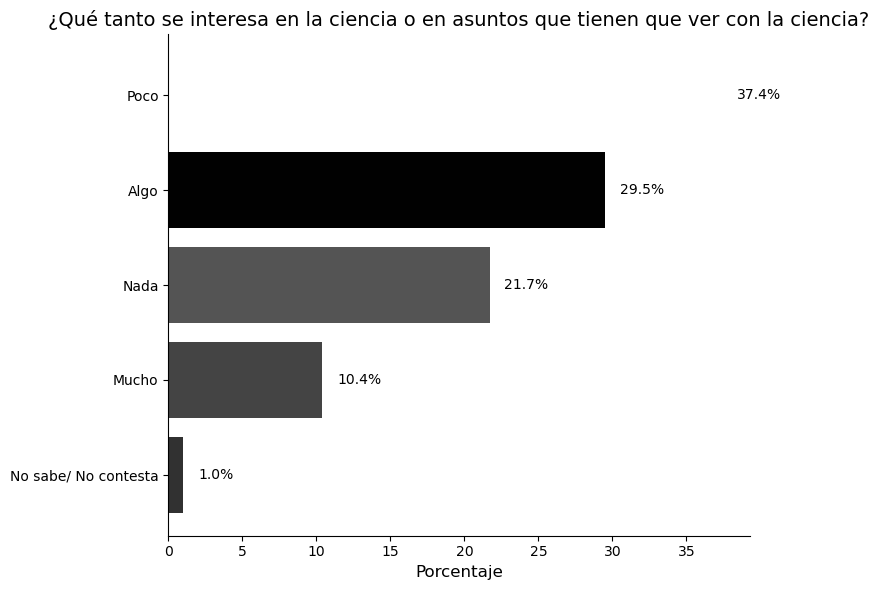

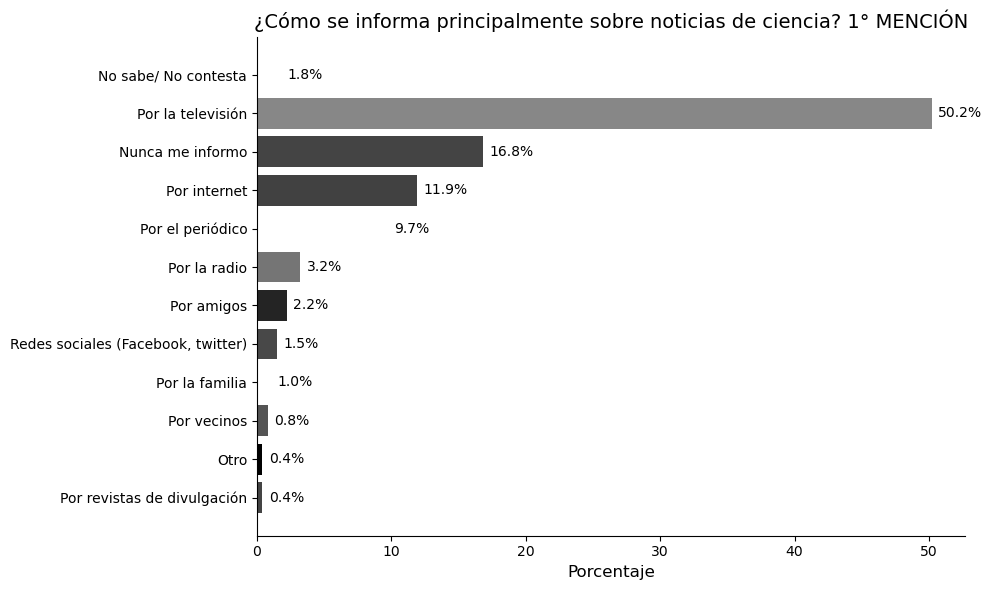

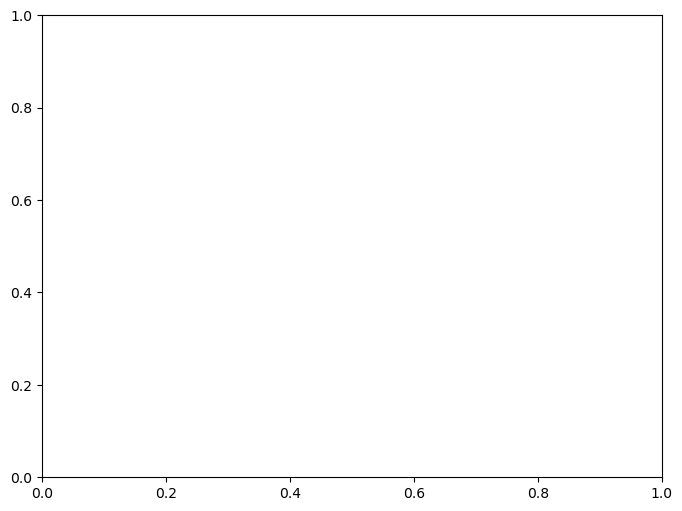

In [125]:
tmp_plot_res_dict = {}

tmp_plot_res_dict= exec(tmp_agg_out_lst)

for ky in tmp_plot_res_dict.keys():
    print(f"---\n{ky}:\n")
    print(tmp_plot_res_dict[ky]['description'])
    print("\n---\n")
    exec(tmp_plot_res_dict[ky]['plot'])

In [94]:

tmp_ans_lst = [answers[ky].text.replace('tmp_plot_res_dict = {}\n', '') for ky in answers.keys()]
tmp_agg_ans_lst = [ans_st.strip("```python").replace("```", '\n').replace('python', '') for ans_st in tmp_ans_lst]
tmp_agg_out_lst = ''.join(tmp_agg_ans_lst)

exec(tmp_agg_out_lst)
## TODO: arreglar esto. 

SyntaxError: unterminated string literal (detected at line 143) (<string>, line 143)

In [ ]:
# reimportar el dict devuelto por el modelo
import ast

answer_text = answer.text.strip("```python").strip("```")
sel_dict = ast.literal_eval(answer_text)
sel_dict

In [ ]:
tmp_sel_dict = {k.split('|')[1]:v for k,v in sel_dict.items()}

{'p33': 'En su opinión ¿qué tan comprometidos están los científicos mexicanos con la sociedad?',
 'p45_1': 'Ahora  dígame  por favor, ¿qué tan de acuerdo o desacuerdo está usted con los siguientes enunciados? La ciencia es demasiado especializada para que yo pueda entenderla',
 'p50_4': 'Indíqueme por favor qué tanta confianza le tiene a la investigación que se realiza en las siguientes disciplinas: Ciencias sociales',
 'p34': 'Para usted, ¿qué tanto ha contribuido la ciencia mexicana  a solucionar los problemas del país?',
 'p36': '¿Qué tan importante es para usted el conocimiento científico?',
 'p52': '¿Qué tan importante es para México generar tecnología propia?',
 'p11': '¿Qué tanto se interesa en la ciencia o en asuntos que tienen que ver con la ciencia?',
 'p37_6': 'Dígame por favor, ¿qué tan fácil o difícil es para usted entender lo que se dice sobre los siguientes temas?: Cultivos transgénicos',
 'p13_1': '¿Cómo se informa principalmente sobre noticias de ciencia? 1° MENCIÓN',


'p52'

In [283]:
tmp_val_etq_dict['p52']

{1.0: 'Muy importante',
 2.0: 'Importante',
 3.0: 'Regular',
 4.0: 'Poco importante',
 5.0: 'Nada importante',
 9.0: 'No sabe/ No contesta'}

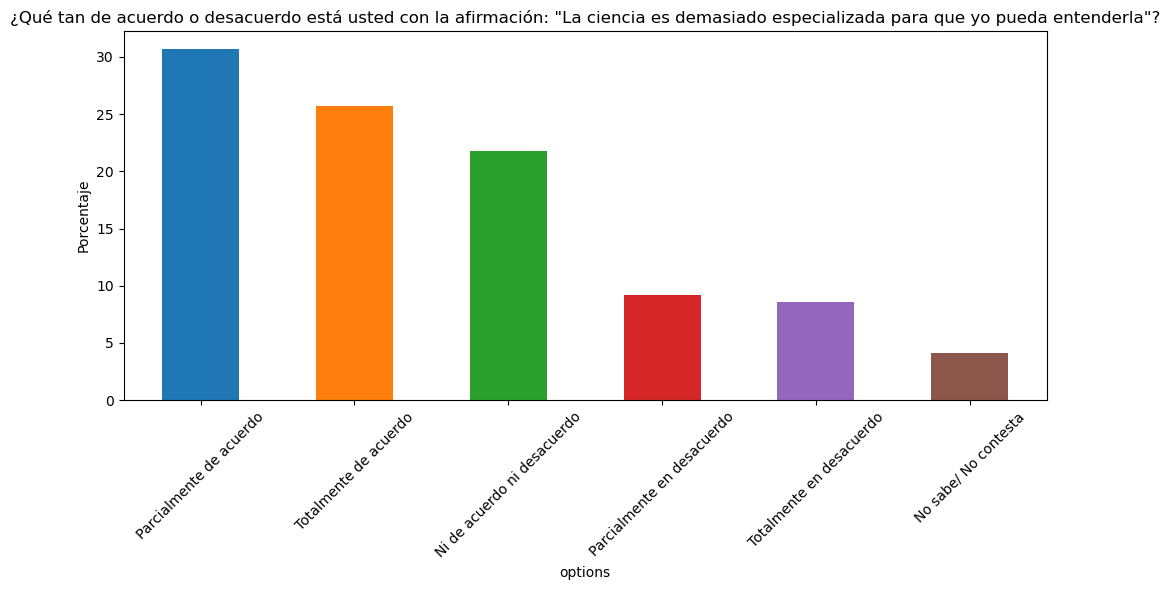

In [321]:
import pandas as pd
import matplotlib.pyplot as plt
import io

data = {'options': ['Parcialmente de acuerdo', 'Totalmente de acuerdo', 'Ni de acuerdo ni desacuerdo', 'Parcialmente en desacuerdo', 'Totalmente en desacuerdo', 'No sabe/ No contesta'],
        'percentage': [30.7, 25.7, 21.8, 9.2, 8.6, 4.1]}

df = pd.DataFrame(data)
df = df.set_index('options')
df.columns = ['p45_1']

# Creating the plot
def create_plot(df):
    fig, ax = plt.subplots(figsize=(10, 6))
    df['p45_1'].sort_values(ascending=False).plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']) # Use different colors
    ax.set_ylabel('Porcentaje')
    ax.set_title('¿Qué tan de acuerdo o desacuerdo está usted con la afirmación: "La ciencia es demasiado especializada para que yo pueda entenderla"?')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    
    # # Convert plot to base64 string
    # img_data = io.BytesIO()
    # fig.savefig(img_data, format='png')
    # img_data.seek(0)
    
    return fig

plot = create_plot(df)
plt.show()

In [271]:
enc_dict[enc_ID]['dataframe'][tmp_var_lst].describe()

,p33,p45_1,p50_4,p34,p36,p52,p11,p37_6,p13_1,p35
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1194.000000,1200.000000,1200.000000,1200.000000
mean,2.633333,2.665833,2.445833,2.900833,2.292500,1.850833,2.771357,3.781667,6.067500,2.542500
std,1.970734,1.697518,1.966033,1.939278,1.457297,1.444641,1.095820,1.678197,13.121411,1.534108
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,3.000000,2.000000,2.000000
50%,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,4.000000,2.000000,2.000000
75%,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,3.000000,4.000000,7.000000,3.000000
max,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,99.000000,9.000000


In [ ]:
# # generación aumentada: prompt + pregunta + documentos 

# query_oneline = query.replace("\n", " ")

# # This prompt is where you can specify any guidance on tone, or what topics the model should stick to, or avoid.
# prompt = f"""You are a helpful and informative bot that answers questions using text from the reference passage included below. 
# Be sure to respond in a complete sentence, being comprehensive, including all relevant background information. 
# However, you are talking to a non-technical audience, so be sure to break down complicated concepts and 
# strike a friendly and converstional tone. If the passage is irrelevant to the answer, you may ignore it.

# QUESTION: {query_oneline}
# """

# # Add the retrieved documents to the prompt.
# for passage in all_passages:
#     passage_oneline = passage.replace("\n", " ")
#     prompt += f"PASSAGE: {passage_oneline}\n"

# print(prompt)

In [ ]:
# las columnas terminadas en 'a' son aparentemente idénticas a las que no... 

filtered_columns = enc_dict['Ciencia_y_Tecnologia']['dataframe'].filter(regex='^p.*a$')
value_counts_df = pd.DataFrame({col: filtered_columns[col].value_counts() for col in filtered_columns.columns}).fillna(0).astype(int)
filtered_columns, value_counts_df

(      p14_1a  p14_2a  p14_3a  p15_1a  p15_2a  p15_3a  p20_1a  p20_2a  p20_3a  \
 0        3.0     2.0     5.0     9.0     6.0     7.0    10.0     5.0     4.0   
 1        2.0     3.0     4.0    12.0     6.0     NaN     NaN     NaN     NaN   
 2        3.0     5.0     4.0     7.0     2.0     6.0     2.0     6.0    10.0   
 3        3.0     5.0     NaN     2.0     7.0    10.0     6.0    10.0     4.0   
 4        9.0     NaN     NaN    11.0     NaN     NaN     NaN     NaN     NaN   
 ...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
 1195     3.0     4.0     NaN     1.0     NaN     NaN     NaN     NaN     NaN   
 1196     3.0     5.0     NaN     3.0     NaN     NaN     4.0    10.0     NaN   
 1197     3.0     4.0     NaN     2.0     3.0     7.0     NaN     NaN     NaN   
 1198     3.0     5.0     NaN     1.0     2.0     7.0     1.0     4.0    10.0   
 1199     3.0     NaN     NaN     2.0     1.0     NaN     NaN     NaN     NaN   
 
       p29_1a  p29_2a  p29

In [ ]:
filtered_columns.columns.str.rstrip('a')
enc_dict['Ciencia_y_Tecnologia']['dataframe'][filtered_columns.columns.str.rstrip('a')]

,p14_1,p14_2,p14_3,p15_1,p15_2,p15_3,p20_1,p20_2,p20_3,p29_1,p29_2,p29_3,p46_1,p46_2,p46_3,p47_1,p47_2,p47_3,p53,p54
0,3.0,2.0,5.0,9.0,6.0,7.0,10.0,5.0,4.0,10.0,4.0,6.0,10.0,1.0,7.0,3.0,9.0,1.0,2.0,2.0
1,2.0,3.0,4.0,12.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,9.0,3.0,4.0,7.0,2.0,2.0
2,3.0,5.0,4.0,7.0,2.0,6.0,2.0,6.0,10.0,NaN,NaN,NaN,7.0,1.0,10.0,7.0,1.0,10.0,2.0,1.0
3,3.0,5.0,NaN,2.0,7.0,10.0,6.0,10.0,4.0,NaN,NaN,NaN,5.0,4.0,10.0,2.0,6.0,7.0,2.0,2.0
4,9.0,NaN,NaN,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.0,NaN,NaN,1.0,6.0,10.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,3.0,4.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,2.0,NaN,5.0,2.0,NaN,2.0,2.0
1196,3.0,5.0,NaN,3.0,NaN,NaN,4.0,10.0,NaN,NaN,NaN,NaN,8.0,6.0,10.0,8.0,6.0,10.0,2.0,2.0
1197,3.0,4.0,NaN,2.0,3.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,5.0,10.0,2.0,5.0,10.0,2.0,2.0
1198,3.0,5.0,NaN,1.0,2.0,7.0,1.0,4.0,10.0,1.0,4.0,NaN,2.0,9.0,10.0,2.0,9.0,10.0,2.0,2.0


In [110]:
result

Index(['p1_1a_1', 'p1_2a_1', 'p1_3a_1', 'p2_1a_1', 'p2_2a_1', 'p2_3a_1',
       'p14_1a', 'p14_2a', 'p14_3a', 'p15_1a', 'p15_2a', 'p15_3a', 'p20_1a',
       'p20_2a', 'p20_3a', 'p29_1a', 'p29_2a', 'p29_3a', 'p46_1a', 'p46_2a',
       'p46_3a', 'p47_1a', 'p47_2a', 'p47_3a', 'p53a', 'p53aa_1', 'p54a'],
      dtype='object')

In [114]:
result_a = enc_dict['Ciencia_y_Tecnologia']['dataframe'].filter(regex='^p.*a$').columns
base_a = [col.rstrip('_a') for col in result_a]
enc_dict['Ciencia_y_Tecnologia']['dataframe'][base_a].describe()

# base_colnames = [col.rstrip('a_1').rstrip('_a') for col in result]
# matching_colnames = [col for col in enc_dict['Ciencia_y_Tecnologia']['dataframe'].columns if any(base in col for base in base_colnames)]
# result, base_colnames, matching_colnames

,p14_1,p14_2,p14_3,p15_1,p15_2,p15_3,p20_1,p20_2,p20_3,p29_1,p29_2,p29_3,p46_1,p46_2,p46_3,p47_1,p47_2,p47_3,p53,p54
count,1200.000000,623.000000,312.000000,1200.000000,728.000000,457.000000,322.000000,226.000000,153.000000,308.000000,173.000000,87.000000,1200.000000,1006.000000,849.000000,1200.000000,975.000000,802.000000,1200.000000,1200.000000
mean,6.783333,3.762440,4.227564,8.190833,4.295330,5.750547,7.478261,5.420354,6.882353,6.081169,5.369942,6.172414,13.755000,5.516899,6.799764,13.255000,5.502564,7.056110,11.133333,2.110000
std,15.401430,1.487807,1.969905,16.777733,2.920191,3.025318,15.013011,2.988174,3.069247,10.966483,2.724057,2.548173,29.463877,7.160923,2.948049,28.608513,2.780791,2.859261,28.512711,1.316945
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,5.000000,1.000000,2.000000,5.000000,2.000000,3.000000,5.000000,2.000000,2.000000
50%,3.000000,4.000000,4.000000,6.000000,3.000000,6.000000,4.000000,5.000000,7.000000,4.000000,5.000000,6.000000,3.000000,5.000000,7.000000,3.000000,6.000000,8.000000,2.000000,2.000000
75%,5.000000,5.000000,5.000000,10.000000,7.000000,8.000000,8.000000,8.000000,10.000000,6.000000,7.000000,8.000000,7.000000,7.000000,9.000000,7.000000,7.000000,9.000000,2.000000,2.000000
max,99.000000,13.000000,12.000000,99.000000,14.000000,14.000000,99.000000,14.000000,14.000000,99.000000,15.000000,13.000000,99.000000,99.000000,17.000000,99.000000,15.000000,14.000000,99.000000,9.000000


In [115]:
enc_dict['Ciencia_y_Tecnologia']['dataframe'].filter(regex='^p.*a$').describe()


,p14_1a,p14_2a,p14_3a,p15_1a,p15_2a,p15_3a,p20_1a,p20_2a,p20_3a,p29_1a,p29_2a,p29_3a,p46_1a,p46_2a,p46_3a,p47_1a,p47_2a,p47_3a,p53a,p54a
count,1200.000000,623.000000,312.000000,1200.000000,728.000000,457.000000,322.000000,226.000000,153.000000,308.000000,173.000000,87.000000,1200.000000,1006.000000,849.000000,1200.000000,975.000000,802.000000,1200.00000,171.000000
mean,6.783333,3.756019,4.208333,8.180000,4.281593,5.746171,7.391304,5.407080,6.862745,5.925325,5.271676,6.137931,13.751667,5.512922,6.792697,13.241667,5.495385,7.052369,2.96250,12.321637
std,15.401430,1.455069,1.902324,16.774547,2.878864,3.014787,14.982097,2.956386,3.032844,10.883643,2.482768,2.473922,29.463708,7.155093,2.927890,28.608308,2.761894,2.852119,12.33523,27.966504
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-1.00000,1.000000
25%,3.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,5.000000,1.000000,2.000000,5.000000,2.000000,3.000000,5.000000,-1.00000,2.000000
50%,3.000000,4.000000,4.000000,6.000000,3.000000,6.000000,4.000000,5.000000,7.000000,4.000000,5.000000,6.000000,3.000000,5.000000,7.000000,3.000000,6.000000,8.000000,-1.00000,4.000000
75%,5.000000,5.000000,5.000000,10.000000,7.000000,8.000000,8.000000,8.000000,10.000000,6.000000,7.000000,8.000000,7.000000,7.000000,9.000000,7.000000,7.000000,9.000000,-1.00000,5.000000
max,99.000000,10.000000,10.000000,99.000000,12.000000,12.000000,99.000000,11.000000,11.000000,99.000000,10.000000,10.000000,99.000000,99.000000,14.000000,99.000000,11.000000,11.000000,99.00000,99.000000


In [ ]:
enc_dict['Ciencia_y_Tecnologia']['metadata']['variable_value_labels']['p16']

{98.0: 'NS', 99.0: 'NC'}

In [ ]:
enc_dict['Ciencia_y_Tecnologia']['dataframe']['p16']

0       5.0
1       2.0
2       6.0
3       7.0
4       6.0
       ... 
1195    3.0
1196    6.0
1197    5.0
1198    8.0
1199    6.0
Name: p16, Length: 1200, dtype: float64

In [ ]:
pregs_dict.values()

dict_values(['¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 1° MENCIÓN', '¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 2° MENCIÓN', '¿Podría decirme, por favor, tres palabras que asocies con la palabra CIENCIA? 3° MENCIÓN', '¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 1° MENCIÓN', '¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 2° MENCIÓN', '¿Podría decirme, por favor, tres palabras que asocies con la palabra CIENCIA? 3° MENCIÓN', 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  1° MENCIÓN', 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  2° MENCIÓN', 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  3° MENCIÓN', 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  1° M

In [ ]:
from collections import Counter

# Identify non-unique elements in the list
non_unique_elements = [item for item, count in Counter(list(pregs_dict.values())).items() if count > 1]
non_unique_elements

['¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 1° MENCIÓN',
 '¿Podría decirme, por favor, tres palabras que asocie con la palabra CIENCIA? 2° MENCIÓN',
 '¿Podría decirme, por favor, tres palabras que asocies con la palabra CIENCIA? 3° MENCIÓN',
 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  1° MENCIÓN',
 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  2° MENCIÓN',
 'Ahora le voy a pedir que me diga, por favor, tres palabras que asocie con la palabra TECNOLOGÍA.  3° MENCIÓN',
 ' 14 Además de la ESCUELA, ¿En qué lugares escucha más hablar sobre ciencia?  1° MENCIÓN',
 ' 14 Además de la ESCUELA, ¿En qué lugares escucha más hablar sobre ciencia?  2° MENCIÓN',
 ' 14 Además de la ESCUELA, ¿En qué lugares escucha más hablar sobre ciencia?  3° MENCIÓN',
 ' 15 Cuando estaba en la escuela o en sus estudios ¿De quién o quienes recibía (recibe) apoyo para realizar

In [ ]:
len(non_unique_elements)

25

### sigue debajo

In [28]:
# crea un ciente de chromadb - y fija document_mode a True

# import chromadb

# DB_NAME = "googlecardb"

# embed_fn = GeminiEmbeddingFunction()
# embed_fn.document_mode = True

# chroma_client = chromadb.Client()
# db = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=embed_fn)

# db.add(documents=documents, ids=[str(i) for i in range(len(documents))])

In [29]:
# db.count(), db.peek()

In [30]:
# results = db.get()

# results

# print("IDs:", results["ids"])
# print("Documents:", results["documents"])
# print("Embeddings:", results["embeddings"])
# print("Metadatas:", results["metadatas"])

# # ChromaDB does not store embeddings by default for efficiency reasons.
# # To retrieve embeddings, you need to query the database instead of using `db.get()`.

# query_results = db.query(query_texts=[""], n_results=db.count())
# print("Embeddings:", query_results["embeddings"])

In [31]:
# # Switch to query mode when generating embeddings.
# embed_fn.document_mode = False

# # Search the Chroma DB using the specified query.
# query = "How do you use the touchscreen to play music?"

# result = db.query(query_texts=[query], n_results=1)
# [all_passages] = result["documents"]

# Markdown(all_passages[0])

In [32]:
# # generación aumentada: prompt + pregunta + documentos 

# query_oneline = query.replace("\n", " ")

# # This prompt is where you can specify any guidance on tone, or what topics the model should stick to, or avoid.
# prompt = f"""You are a helpful and informative bot that answers questions using text from the reference passage included below. 
# Be sure to respond in a complete sentence, being comprehensive, including all relevant background information. 
# However, you are talking to a non-technical audience, so be sure to break down complicated concepts and 
# strike a friendly and converstional tone. If the passage is irrelevant to the answer, you may ignore it.

# QUESTION: {query_oneline}
# """

# # Add the retrieved documents to the prompt.
# for passage in all_passages:
#     passage_oneline = passage.replace("\n", " ")
#     prompt += f"PASSAGE: {passage_oneline}\n"

# print(prompt)

In [33]:
# answer = client.models.generate_content(
#     model="gemini-2.0-flash",
#     contents=prompt)

# Markdown(answer.text)

#### similarity scores

In [34]:
# calcular la similitud entre documentos

texts = [
    'The quick brown fox jumps over the lazy dog.',
    'The quick rbown fox jumps over the lazy dog.',
    'teh fast fox jumps over the slow woofer.',
    'a quick brown fox jmps over lazy dog.',
    'brown fox jumping over dog',
    'fox > dog',
    # Alternative pangram for comparison:
    'The five boxing wizards jump quickly.',
    # Unrelated text, also for comparison:
    'Lorem ipsum dolor sit amet, consectetur adipiscing elit. Vivamus et hendrerit massa. Sed pulvinar, nisi a lobortis sagittis, neque risus gravida dolor, in porta dui odio vel purus.',
]


response = client.models.embed_content(
    model='models/text-embedding-004',
    contents=texts,
    config=types.EmbedContentConfig(task_type='semantic_similarity'))

In [35]:
# el modelo de embeddings como diccionario y los embeddings directos    
response.model_dump(), response.embeddings

({'embeddings': [{'values': [-0.0922682,
     0.012113783,
     -0.0063794684,
     0.0369048,
     0.02203019,
     0.048805293,
     0.0133289965,
     0.021541007,
     0.02705553,
     -0.0043925485,
     -0.011962657,
     0.069833845,
     0.010891116,
     0.06149802,
     0.049922608,
     0.022119658,
     0.0178632,
     0.050096616,
     0.0029887455,
     -0.008278692,
     0.005999019,
     -0.0040636063,
     0.015202278,
     -0.021813663,
     -0.02274539,
     -0.032121718,
     -0.00033075613,
     -0.022031343,
     0.028694874,
     -0.04976425,
     0.025347114,
     0.07245508,
     0.003248612,
     -0.002201165,
     0.059787363,
     -0.0057624904,
     -0.02634191,
     -0.003782781,
     0.048398733,
     0.0066004205,
     -0.05704449,
     -0.022870814,
     -0.058460187,
     0.013212032,
     0.01834201,
     -0.076267265,
     -0.02015255,
     0.014425502,
     0.0024263572,
     -0.011807308,
     0.056245767,
     -0.0031448188,
     0.0013501083,
   

In [36]:
# la longitud de los embeddings es fija
len(response.embeddings[0].values)

768

In [37]:
# truncar datos para visualización

def truncate(t: str, limit: int = 50) -> str:
  """Truncate labels to fit on the chart."""
  if len(t) > limit:
    return t[:limit-3] + '...'
  else:
    return t

truncated_texts = [truncate(t) for t in texts]

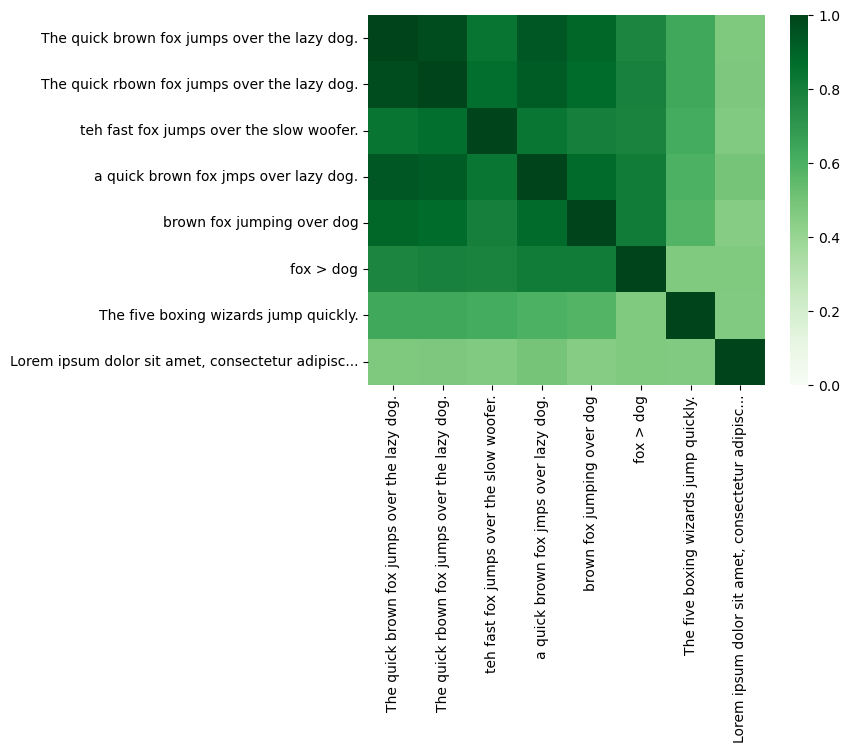

In [38]:
# la similaridad se calcula como el producto punto (inner product) entre los vectores de embedding

import pandas as pd
import seaborn as sns


# Set up the embeddings in a dataframe.
df = pd.DataFrame([e.values for e in response.embeddings], index=truncated_texts)

# la matriz de similardad: 
# Perform the similarity calculation
sim = df @ df.T
# Draw!
sns.heatmap(sim, vmin=0, vmax=1, cmap="Greens");

In [39]:
# sim is a similarity matrix calculated as the dot product of embedding vectors.
# Each entry in sim represents the similarity score between two text embeddings.
sim['The quick brown fox jumps over the lazy dog.'].sort_values(ascending=False)

The quick brown fox jumps over the lazy dog.          0.999999
The quick rbown fox jumps over the lazy dog.          0.975623
a quick brown fox jmps over lazy dog.                 0.939730
brown fox jumping over dog                            0.894507
teh fast fox jumps over the slow woofer.              0.842152
fox > dog                                             0.776455
The five boxing wizards jump quickly.                 0.635346
Lorem ipsum dolor sit amet, consectetur adipisc...    0.472174
Name: The quick brown fox jumps over the lazy dog., dtype: float64

#### clasificación de embeddings con Keras

In [40]:
from sklearn.datasets import fetch_20newsgroups

newsgroups_train = fetch_20newsgroups(subset="train")
newsgroups_test = fetch_20newsgroups(subset="test")

# View list of class names for dataset
newsgroups_train.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [41]:
print(newsgroups_train.data[0])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







In [42]:
# # preprocesamiento como un mensaje anónimo

# import email
# import re

# import pandas as pd


# def preprocess_newsgroup_row(data):
#     # Extract only the subject and body
#     msg = email.message_from_string(data)
#     text = f"{msg['Subject']}\n\n{msg.get_payload()}"
#     # Strip any remaining email addresses
#     text = re.sub(r"[\w\.-]+@[\w\.-]+", "", text)
#     # Truncate each entry to 5,000 characters
#     text = text[:5000]

#     return text


# def preprocess_newsgroup_data(newsgroup_dataset):
#     # Put data points into dataframe
#     df = pd.DataFrame(
#         {"Text": newsgroup_dataset.data, "Label": newsgroup_dataset.target}
#     )
#     # Clean up the text
#     df["Text"] = df["Text"].apply(preprocess_newsgroup_row)
#     # Match label to target name index
#     df["Class Name"] = df["Label"].map(lambda l: newsgroup_dataset.target_names[l])

#     return df

In [43]:
# # Apply preprocessing function to training and test datasets
# df_train = preprocess_newsgroup_data(newsgroups_train)
# df_test = preprocess_newsgroup_data(newsgroups_test)

# df_train.head()

,Text,Label,Class Name
0,WHAT car is this!?\n\n I was wondering if anyo...,7,rec.autos
1,SI Clock Poll - Final Call\n\nA fair number of...,4,comp.sys.mac.hardware
2,"PB questions...\n\nwell folks, my mac plus fin...",4,comp.sys.mac.hardware
3,Re: Weitek P9000 ?\n\nRobert J.C. Kyanko () wr...,1,comp.graphics
4,Re: Shuttle Launch Question\n\nFrom article <>...,14,sci.space


In [44]:
# # muestra de datos y selección de mensajes de ciencia
# def sample_data(df, num_samples, classes_to_keep):
#     # Sample rows, selecting num_samples of each Label.
#     df = (
#         df.groupby("Label")[df.columns]
#         .apply(lambda x: x.sample(num_samples))
#         .reset_index(drop=True)
#     )

#     df = df[df["Class Name"].str.contains(classes_to_keep)]

#     # We have fewer categories now, so re-calibrate the label encoding.
#     df["Class Name"] = df["Class Name"].astype("category")
#     df["Encoded Label"] = df["Class Name"].cat.codes

#     return df

In [45]:
# TRAIN_NUM_SAMPLES = 100
# TEST_NUM_SAMPLES = 25
# # Class name should contain 'sci' to keep science categories.
# # Try different labels from the data - see newsgroups_train.target_names
# CLASSES_TO_KEEP = "sci"

# df_train = sample_data(df_train, TRAIN_NUM_SAMPLES, CLASSES_TO_KEEP)
# df_test = sample_data(df_test, TEST_NUM_SAMPLES, CLASSES_TO_KEEP)

In [46]:
# df_train.value_counts("Class Name")

Class Name
sci.crypt          100
sci.electronics    100
sci.med            100
sci.space          100
Name: count, dtype: int64

#### clasificación

In [47]:
## el modelo de embeddings se puede usar para varias tareas

# Task types
# The text-embedding-004 model supports a task type parameter that generates embeddings tailored for the specific task.

# Task Type	Description
# RETRIEVAL_QUERY	Specifies the given text is a query in a search/retrieval setting.
# RETRIEVAL_DOCUMENT	Specifies the given text is a document in a search/retrieval setting.
# SEMANTIC_SIMILARITY	Specifies the given text will be used for Semantic Textual Similarity (STS).
# CLASSIFICATION	Specifies that the embeddings will be used for classification.
# CLUSTERING	Specifies that the embeddings will be used for clustering.
# FACT_VERIFICATION	Specifies that the given text will be used for fact verification.
# For this example you will be performing classification.

In [48]:
# # clasificación de texto

# from google.api_core import retry
# import tqdm
# from tqdm.rich import tqdm as tqdmr
# import warnings

# # Add tqdm to Pandas...
# tqdmr.pandas()

# # ...But suppress the experimental warning.
# warnings.filterwarnings("ignore", category=tqdm.TqdmExperimentalWarning)

# # Define a helper to retry when per-minute quota is reached.
# is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})

# @retry.Retry(predicate=is_retriable, timeout=300.0)
# def embed_fn(text: str) -> list[float]:
#     # You will be performing classification, so set task_type accordingly.
#     response = client.models.embed_content(
#         model="models/text-embedding-004",
#         contents=text,
#         config=types.EmbedContentConfig(
#             task_type="classification",
#         ),
#     )

#     return response.embeddings[0].values


# def create_embeddings(df):
#     df["Embeddings"] = df["Text"].progress_apply(embed_fn)
#     return df

In [49]:
#toma aprox 4 -8 mins

# df_train = create_embeddings(df_train)
# df_test = create_embeddings(df_test)

In [50]:
# df_train.head()

In [51]:
# # construcción de un modelo de clasificación con keras

# import keras
# from keras import layers


# def build_classification_model(input_size: int, num_classes: int) -> keras.Model:
#     return keras.Sequential(
#         [
#             layers.Input([input_size], name="embedding_inputs"),
#             layers.Dense(input_size, activation="relu", name="hidden"),
#             layers.Dense(num_classes, activation="softmax", name="output_probs"),
#         ]
#     )

In [52]:
# # Derive the embedding size from observing the data. The embedding size can also be specified
# # with the `output_dimensionality` parameter to `embed_content` if you need to reduce it.
# embedding_size = len(df_train["Embeddings"].iloc[0])

# classifier = build_classification_model(
#     embedding_size, len(df_train["Class Name"].unique())
# )
# classifier.summary()

# classifier.compile(
#     loss=keras.losses.SparseCategoricalCrossentropy(),
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     metrics=["accuracy"],
# )

In [53]:
# # modelo de clasificación
# # The model is compiled and ready to train.

# import numpy as np


# NUM_EPOCHS = 20
# BATCH_SIZE = 32

# # Split the x and y components of the train and validation subsets.
# y_train = df_train["Encoded Label"]
# x_train = np.stack(df_train["Embeddings"])
# y_val = df_test["Encoded Label"]
# x_val = np.stack(df_test["Embeddings"])

# # Specify that it's OK to stop early if accuracy stabilises.
# early_stop = keras.callbacks.EarlyStopping(monitor="accuracy", patience=3)

# # Train the model for the desired number of epochs.
# history = classifier.fit(
#     x=x_train,
#     y=y_train,
#     validation_data=(x_val, y_val),
#     callbacks=[early_stop],
#     batch_size=BATCH_SIZE,
#     epochs=NUM_EPOCHS,
# )

In [54]:
# evaluación del modelo

# classifier.evaluate(x=x_val, y=y_val, return_dict=True)

In [55]:
# def make_prediction(text: str) -> list[float]:
#     """Infer categories from the provided text."""
#     # Remember that the model takes embeddings as input, so calculate them first.
#     embedded = embed_fn(new_text)

#     # And recall that the input must be batched, so here they are wrapped as a
#     # list to provide a batch of 1.
#     inp = np.array([embedded])

#     # And un-batched here.
#     [result] = classifier.predict(inp)
#     return result

In [56]:
# # This example avoids any space-specific terminology to see if the model avoids
# # biases towards specific jargon.
# new_text = """
# First-timer looking to get out of here.

# Hi, I'm writing about my interest in travelling to the outer limits!

# What kind of craft can I buy? What is easiest to access from this 3rd rock?

# Let me know how to do that please.
# """

# result = make_prediction(new_text)

# for idx, category in enumerate(df_test["Class Name"].cat.categories):
#     print(f"{category}: {result[idx] * 100:0.2f}%")